# Lab 2 - Przetwarzanie danych - Polish companies bancruptcy data

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

# Style configuration matching Lab 1
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 100})

## 1. Wczytanie danych z UCIML Repo

Pobieramy zbiór "Polish companies bankruptcy". Zbiór jest oznaczony w `ucimlrepo` jako ID 365 i oryginalnie składa się z 5 osobnych przedziałów czasowych (odpowiednio 1 rok do 5 lat przed potencjalnym bankructwem). Połączymy je w jeden główny zbiór do analizy całościowej wzorców bankructwa.

In [2]:
bankruptcy_repo = fetch_ucirepo(id=365)

X = bankruptcy_repo.data.features
y = bankruptcy_repo.data.targets

# Pokażmy w jaki sposób UCI zapisuje etykiety
print(f"Dane wejściowe (cechy): {X.shape}")
print(f"Dane wyjściowe (etykiety): {y.shape}")

df = X.copy()
# Upewnienie się co do nazwy kolumny wyjściowej (zazwyczaj 'class' lub 'bankrupt')
target_col_name = y.columns[0]
df['bankrupt'] = y[target_col_name].astype(int)

print(df.head())

#print count of rows for each of the values in "year" column
print(df['year'].value_counts())


Dane wejściowe (cechy): (43405, 65)
Dane wyjściowe (etykiety): (43405, 1)
   year        A1       A2       A3      A4       A5       A6        A7  \
0     1  0.200550  0.37951  0.39641  2.0472  32.3510  0.38825  0.249760   
1     1  0.209120  0.49988  0.47225  1.9447  14.7860  0.00000  0.258340   
2     1  0.248660  0.69592  0.26713  1.5548  -1.1523  0.00000  0.309060   
3     1  0.081483  0.30734  0.45879  2.4928  51.9520  0.14988  0.092704   
4     1  0.187320  0.61323  0.22960  1.4063  -7.3128  0.18732  0.187320   

        A8      A9  ...       A56      A57      A58       A59     A60     A61  \
0  1.33050  1.1389  ...  0.121960  0.39718  0.87804  0.001924  8.4160  5.1372   
1  0.99601  1.6996  ...  0.121300  0.42002  0.85300  0.000000  4.1486  3.2732   
2  0.43695  1.3090  ...  0.241140  0.81774  0.76599  0.694840  4.9909  3.9510   
3  1.86610  1.0571  ...  0.054015  0.14207  0.94598  0.000000  4.5746  3.6147   
4  0.63070  1.1559  ...  0.134850  0.48431  0.86515  0.124440  6.3985 

In [3]:
# Wczytanie mapowania nazw cech i utworzenie czytelnego widoku danych
import json
from pathlib import Path

mapping_path_candidates = [
    Path("feature_name_mapping.json"),
    Path("notebooks/lab2/feature_name_mapping.json"),
 ]

mapping_path = next((p for p in mapping_path_candidates if p.exists()), None)
if mapping_path is None:
    raise FileNotFoundError("Nie znaleziono feature_name_mapping.json")

with open(mapping_path, "r", encoding="utf-8") as f:
    feature_mapping_payload = json.load(f)

feature_mapping = feature_mapping_payload["mapping"]
df_readable = df.rename(columns=feature_mapping).copy()

print(f"Wczytano mapowanie z: {mapping_path}")
print(f"Liczba zmapowanych cech: {len(feature_mapping)}")
display(df_readable.head(2))

Wczytano mapowanie z: feature_name_mapping.json
Liczba zmapowanych cech: 64


,year,net profit / total assets,total liabilities / total assets,working capital / total assets,current assets / short-term liabilities,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,retained earnings / total assets,EBIT / total assets,book value of equity / total liabilities,sales / total assets,...,(sales - cost of products sold) / sales,(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation),total costs /total sales,long-term liabilities / equity,sales / inventory,sales / receivables,(short-term liabilities *365) / sales,sales / short-term liabilities,sales / fixed assets,bankrupt
0,1,0.20055,0.37951,0.39641,2.0472,32.351,0.38825,0.24976,1.33050,1.1389,...,0.12196,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1,0.20912,0.49988,0.47225,1.9447,14.786,0.00000,0.25834,0.99601,1.6996,...,0.12130,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0


## 2. Eksploracyjna Analiza Danych (EDA)

Zanim przejdziemy do modelowania i transformacji, należy zbadać naturę danych: ilości braków, ewentualne ukryte wartości odstające oraz co najważniejsze - spojrzeć na dystrybucję klas docelowych. Zbiory dotyczące bankructw cechują się **silnym brakiem zbalansowania**.


Dystrybucja klas:


,Count,Percentage %
bankrupt,,
0,41314,95.18
1,2091,4.82


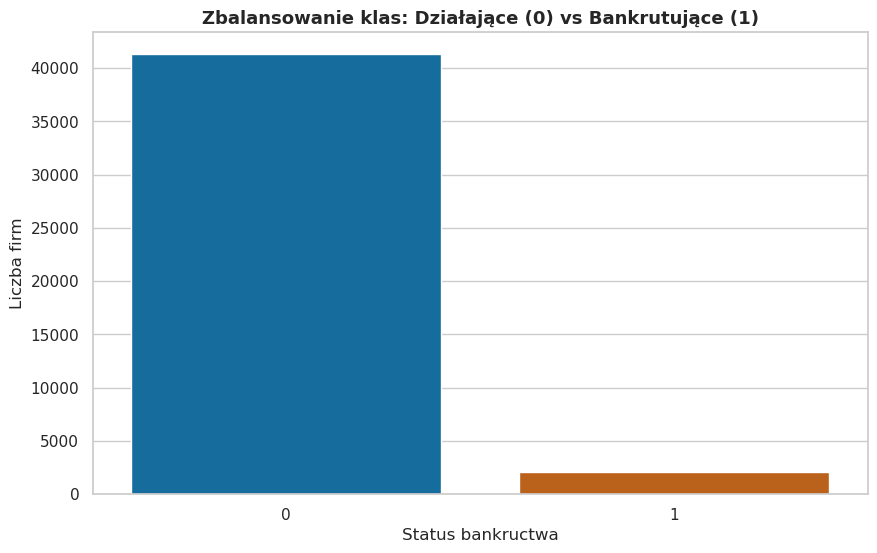

In [4]:
# Dystrybucja klasy docelowej (Bankrut vs Działająca firma)
class_counts = df['bankrupt'].value_counts()
class_percentages = (class_counts / len(df) * 100).round(2)

print("\nDystrybucja klas:")
display(pd.DataFrame({'Count': class_counts, 'Percentage %': class_percentages}))

sns.countplot(data=df, x='bankrupt', hue='bankrupt', palette={0: "#0072B2", 1: "#D55E00"}, legend=False)
plt.title("Zbalansowanie klas: Działające (0) vs Bankrutujące (1)", fontsize=13, fontweight='bold')
plt.ylabel("Liczba firm")
plt.xlabel("Status bankructwa")
plt.show()

### Odzyskanie horyzontu ram czasowych (Z metadanych)

Z informacji o zbiorze wiemy, że dane składają się oryginalnie z 5 połączonych transz, różniących się okresem ostrzegania.
Ponieważ ucimlrepo złączyło je w zbitkę, możemy zrekonstruować wskaźnik 'Year' (horyzont od 5 lat do 1 roku przed bankructwem) na podstawie wprost przypisanej w literaturze struktury rzędów. To kluczowe, bo natura danych bankrutów zazwyczaj najmocniej dewiuje w 1st i 2ndYear (tuż przed upadkiem).

Poprawnie wyliczono years_to_prediction na podstawie kolumny year (6 - year).


,samples,bankrupt_count,bankrupt_rate_%
years_to_prediction,,,
5,7027,271,3.86
4,10173,400,3.93
3,10503,495,4.71
2,9792,515,5.26
1,5910,410,6.94


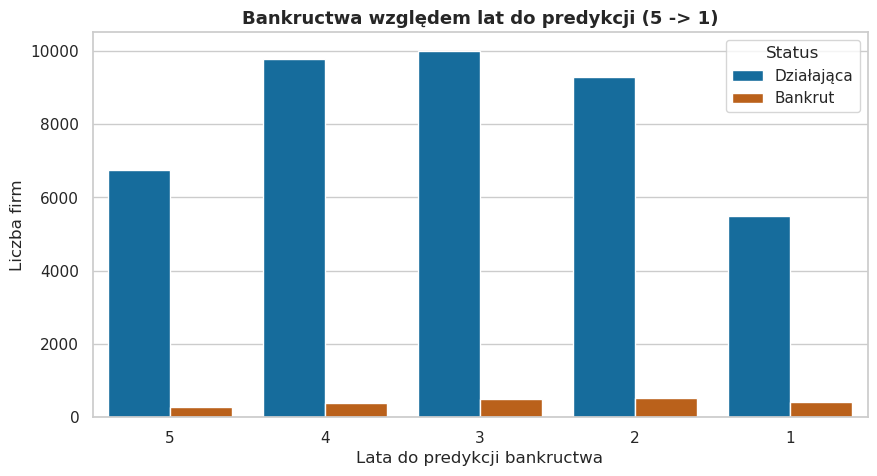

In [5]:
# Rekonstrukcja osi czasu bez hardcodowania liczebności transz
if 'year' not in df.columns:
    raise KeyError("Brak kolumny 'year' w danych wejściowych.")

year_numeric = pd.to_numeric(df['year'], errors='coerce')
invalid_year_mask = year_numeric.isna()

if invalid_year_mask.any():
    bad_count = int(invalid_year_mask.sum())
    raise ValueError(f"Kolumna 'year' zawiera {bad_count} nie-numerycznych wartości.")

# years_to_prediction = 6 - year (np. year=1 -> 5 lat do predykcji)
df['years_to_prediction'] = 6 - year_numeric.astype(int)

if not df['years_to_prediction'].between(1, 5).all():
    bad_vals = sorted(df.loc[~df['years_to_prediction'].between(1, 5), 'years_to_prediction'].unique())
    raise ValueError(f"Wykryto years_to_prediction poza zakresem 1..5: {bad_vals}")

print("Poprawnie wyliczono years_to_prediction na podstawie kolumny year (6 - year).")

year_summary = (
    df.groupby('years_to_prediction')
    .agg(
        samples=('bankrupt', 'size'),
        bankrupt_count=('bankrupt', 'sum')
    )
    .sort_index(ascending=False)
)
year_summary['bankrupt_rate_%'] = (
    year_summary['bankrupt_count'] / year_summary['samples'] * 100
).round(2)
display(year_summary)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='years_to_prediction',
    hue='bankrupt',
    order=[5, 4, 3, 2, 1],
    palette={0: "#0072B2", 1: "#D55E00"}
)
plt.title("Bankructwa względem lat do predykcji (5 -> 1)", fontsize=13, fontweight='bold')
plt.ylabel("Liczba firm")
plt.xlabel("Lata do predykcji bankructwa")
plt.legend(title='Status', labels=['Działająca', 'Bankrut'])
plt.show()

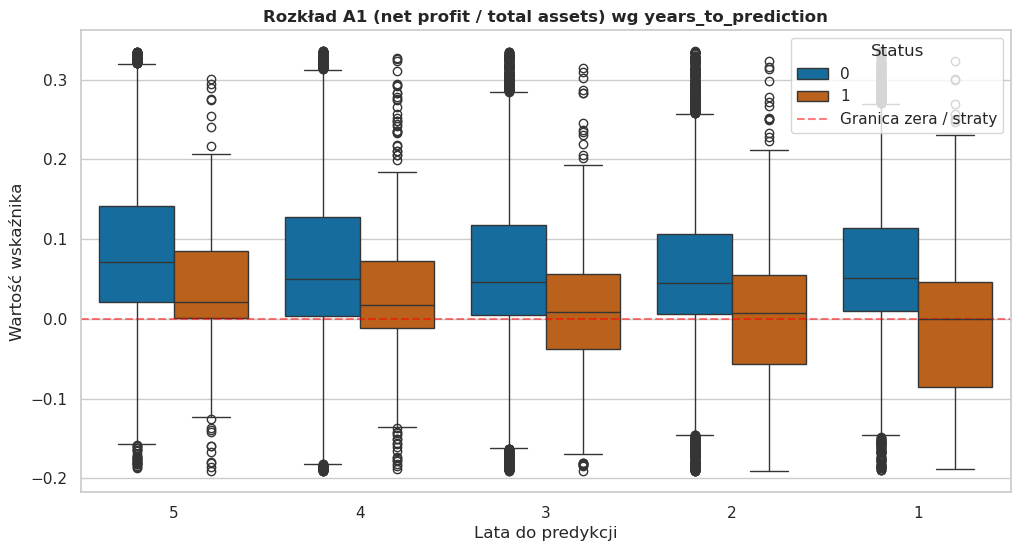

In [6]:
# Atrybuty w zbiorze są nazwane jako A1..A64; A1 odpowiada opisanemu w dokumentacji X1
feature_to_plot = 'A1'

plt.figure(figsize=(12, 6))
q_low = df[feature_to_plot].quantile(0.05)
q_hi = df[feature_to_plot].quantile(0.95)

filtered_df = df[(df[feature_to_plot] < q_hi) & (df[feature_to_plot] > q_low)]

sns.boxplot(
    data=filtered_df,
    x='years_to_prediction',
    y=feature_to_plot,
    hue='bankrupt',
    order=[5, 4, 3, 2, 1],
    palette={0: "#0072B2", 1: "#D55E00"}
 )
plt.title(f"Rozkład {feature_to_plot} (net profit / total assets) wg years_to_prediction", fontsize=12, fontweight='bold')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Granica zera / straty')
plt.ylabel("Wartość wskaźnika")
plt.xlabel("Lata do predykcji")
plt.legend(title='Status', loc='upper right')
plt.show()

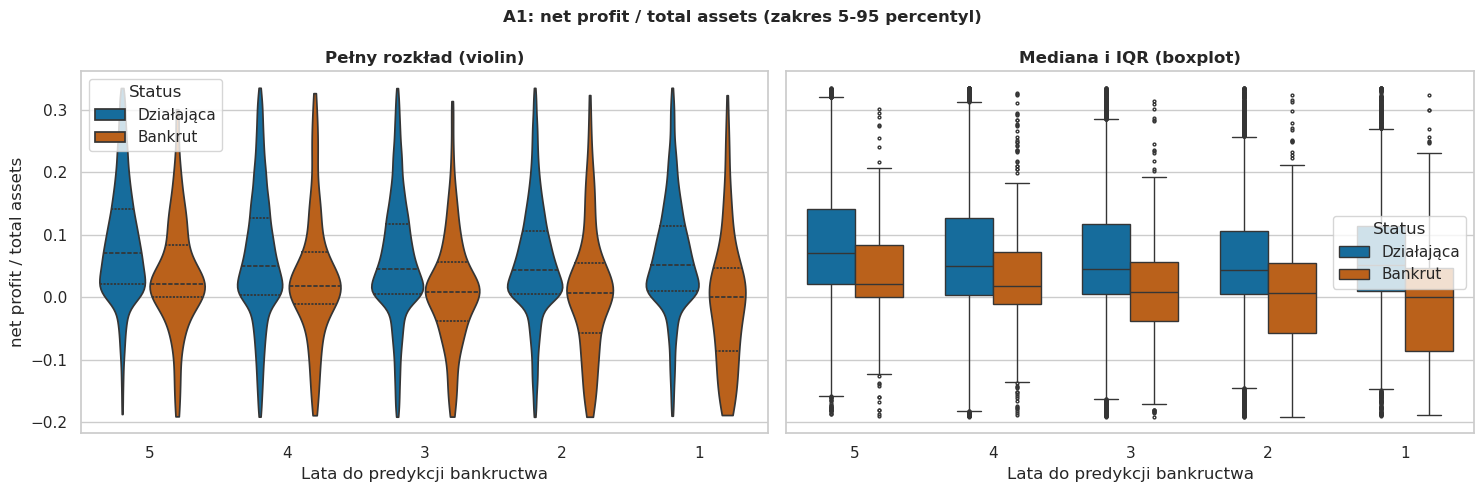

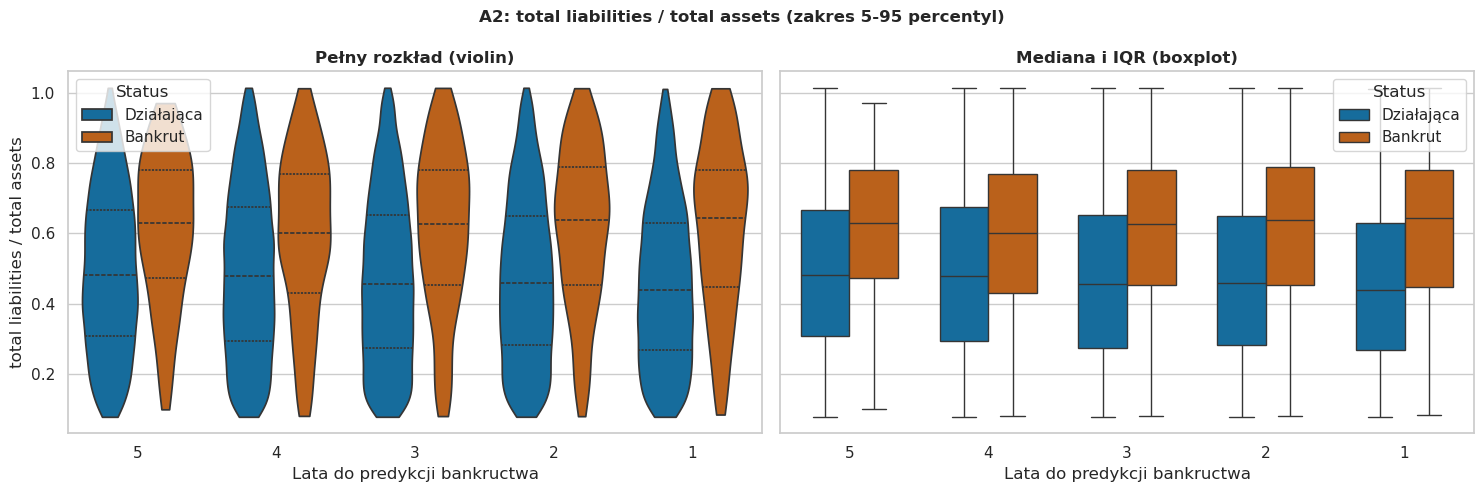

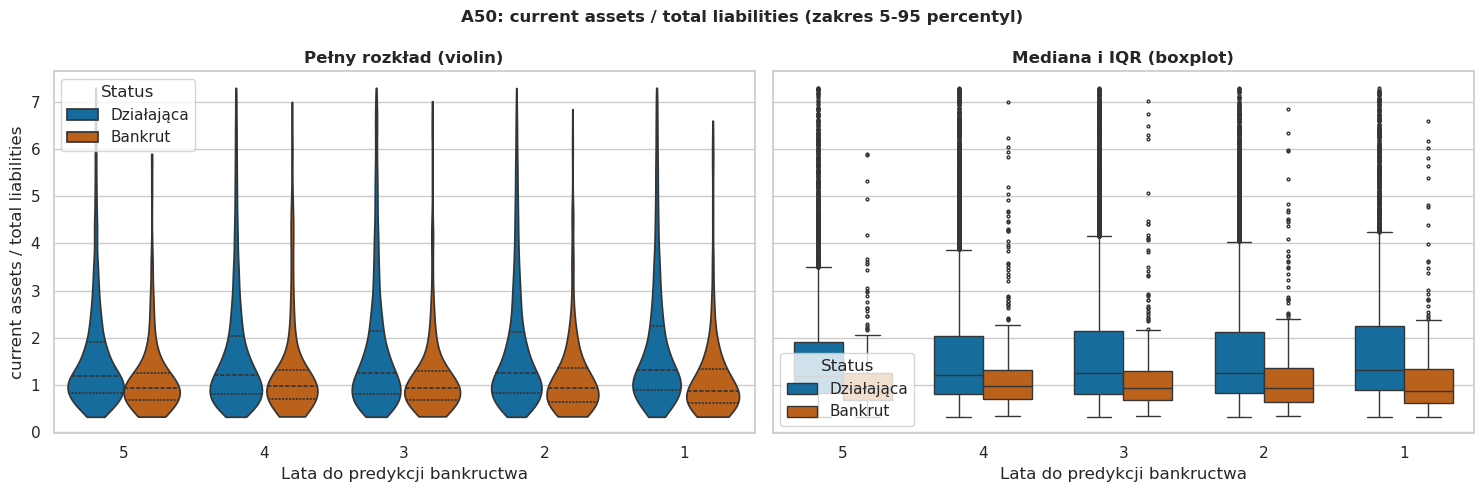

In [37]:
# Czytelniejsze porównanie rozkładów cech: violin + boxplot per years_to_prediction i klasa
selected_features = ['A1', 'A2', 'A50']
status_palette = {'Działająca': '#0072B2', 'Bankrut': '#D55E00'}

for feature_name in selected_features:
    pretty_name = feature_mapping.get(feature_name, feature_name)
    q_low = df[feature_name].quantile(0.05)
    q_hi = df[feature_name].quantile(0.95)

    # Przycinamy skrajne 5% tylko do wizualizacji (nie modyfikujemy danych źródłowych)
    plot_df = df[(df[feature_name] >= q_low) & (df[feature_name] <= q_hi)].copy()
    plot_df['status'] = plot_df['bankrupt'].map({0: 'Działająca', 1: 'Bankrut'})

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    sns.violinplot(
        data=plot_df,
        x='years_to_prediction',
        y=feature_name,
        hue='status',
        hue_order=['Działająca', 'Bankrut'],
        order=[5, 4, 3, 2, 1],
        palette=status_palette,
        cut=0,
        split=False,
        inner='quartile',
        ax=axes[0]
    )
    axes[0].set_title('Pełny rozkład (violin)', fontweight='bold')
    axes[0].set_xlabel('Lata do predykcji bankructwa')
    axes[0].set_ylabel(pretty_name)
    axes[0].legend(title='Status')

    sns.boxplot(
        data=plot_df,
        x='years_to_prediction',
        y=feature_name,
        hue='status',
        hue_order=['Działająca', 'Bankrut'],
        order=[5, 4, 3, 2, 1],
        palette=status_palette,
        width=0.7,
        fliersize=2,
        ax=axes[1]
    )
    axes[1].set_title('Mediana i IQR (boxplot)', fontweight='bold')
    axes[1].set_xlabel('Lata do predykcji bankructwa')
    axes[1].set_ylabel('')
    axes[1].legend(title='Status')

    plt.suptitle(
        f"{feature_name}: {pretty_name} (zakres 5-95 percentyl)",
        fontsize=12,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

### Braki danych
Dane finansowe często charakteryzują się niekompletnością. Zobaczmy, ile atrybutów ma braki w wartościach i jaka jest ich skala (odsetek z całego zbioru).

Liczba cech z brakami: 64 z 65
Top 10 cech z największą liczbą braków:


,Missing,Percentage %
A37,18984,43.736897
A21,5854,13.486925
A27,2764,6.367930
A60,2152,4.957954
A45,2147,4.946435
A24,922,2.124179
A54,812,1.870752
A28,812,1.870752
A64,812,1.870752
A53,812,1.870752


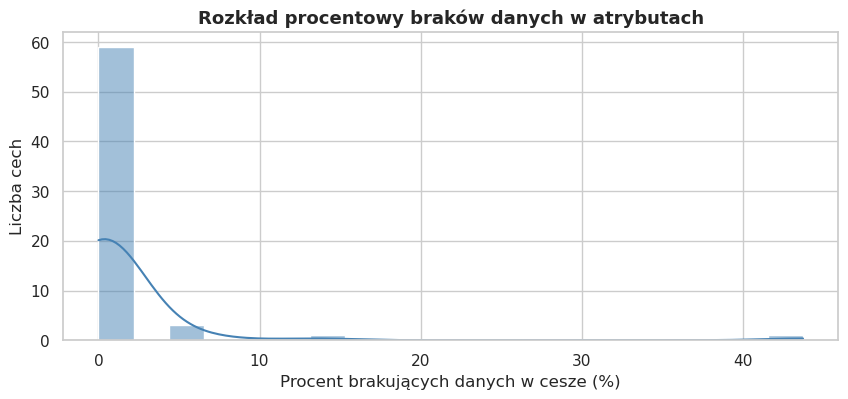


Średni odsetek braków w wierszu per years_to_prediction:


,avg_row_missing_ratio,avg_row_missing_%
years_to_prediction,,
5,0.012394,1.24
4,0.017836,1.78
3,0.014051,1.41
2,0.013377,1.34
1,0.011784,1.18


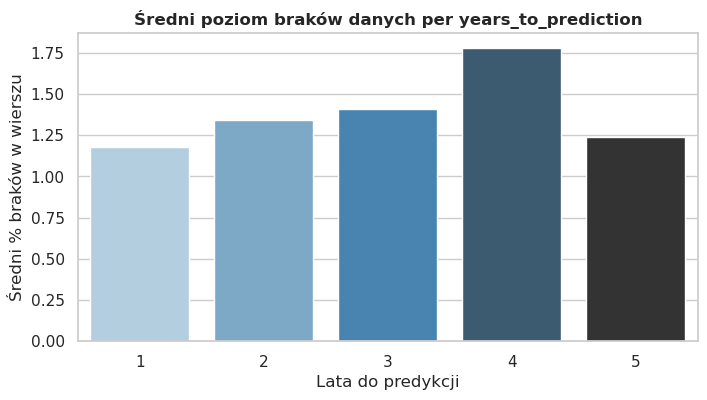


Średni odsetek braków w wierszu per status bankructwa:


,avg_row_missing_ratio,avg_row_missing_%
bankrupt,,
0,0.013744,1.37
1,0.023398,2.34


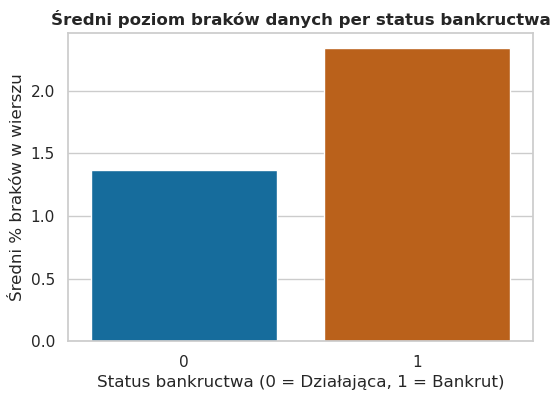

In [8]:
missing_counts = df.isnull().sum()
missing_perc = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({'Missing': missing_counts, 'Percentage %': missing_perc})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values(by='Percentage %', ascending=False)

print(f"Liczba cech z brakami: {len(missing_df)} z {X.shape[1]}")
print("Top 10 cech z największą liczbą braków:")
display(missing_df.head(10))

plt.figure(figsize=(10, 4))
sns.histplot(missing_df['Percentage %'], bins=20, color='steelblue', kde=True)
plt.title("Rozkład procentowy braków danych w atrybutach", fontsize=13, fontweight='bold')
plt.xlabel("Procent brakujących danych w cesze (%)")
plt.ylabel("Liczba cech")
plt.show()

# Missingness per years_to_prediction
row_missing_by_year = (
    df.isna().mean(axis=1)
    .groupby(df['years_to_prediction'])
    .mean()
    .sort_index(ascending=False)
    .rename('avg_row_missing_ratio')
    .to_frame()
 )
row_missing_by_year['avg_row_missing_%'] = (row_missing_by_year['avg_row_missing_ratio'] * 100).round(2)

print("\nŚredni odsetek braków w wierszu per years_to_prediction:")
display(row_missing_by_year)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=row_missing_by_year.index,
    y=row_missing_by_year['avg_row_missing_%'],
    hue=row_missing_by_year.index,
    palette='Blues_d',
    legend=False
 )
plt.title("Średni poziom braków danych per years_to_prediction", fontweight='bold')
plt.xlabel("Lata do predykcji")
plt.ylabel("Średni % braków w wierszu")
plt.show()

# wyświetl średni procent braków wg. bankructwa (bankrupt) - czy bankrutujące firmy mają więcej braków?
row_missing_by_bankrupt = (
    df.isna().mean(axis=1)
    .groupby(df['bankrupt'])
    .mean()
    .rename('avg_row_missing_ratio')
    .to_frame()
)
row_missing_by_bankrupt['avg_row_missing_%'] = (row_missing_by_bankrupt['avg_row_missing_ratio'] * 100).round(2)

print("\nŚredni odsetek braków w wierszu per status bankructwa:")
display(row_missing_by_bankrupt)
plt.figure(figsize=(6, 4))
sns.barplot(
    x=row_missing_by_bankrupt.index,
    y=row_missing_by_bankrupt['avg_row_missing_%'],
    hue=row_missing_by_bankrupt.index,
    palette={0: "#0072B2", 1: "#D55E00"},
    legend=False
)
plt.title("Średni poziom braków danych per status bankructwa", fontweight='bold')
plt.xlabel("Status bankructwa (0 = Działająca, 1 = Bankrut)")
plt.ylabel("Średni % braków w wierszu")
plt.show()

In [9]:
# A37 = current current assets - inventories / long-term liabilities
# sprawdzamy czy brak A37 jest powiazany z brakiem dlugoterminowych zobowiazan (A59)
# A59 = long-term liabilities / equity
a37_missing_a59_counts = df[df['A37'].isna()]['A59'].value_counts(dropna=False)
print("\nLiczba wartości A59 w wierszach, gdzie A37 jest brakujące:")
display(a37_missing_a59_counts)


# A21 =	sales (n) / sales (n-1)
a21_missing_year_counts = df[df['A21'].isna()]['year'].value_counts(dropna=False).sort_index()
print("\nLiczba wierszy z brakującym A21 per year:")
display(a21_missing_year_counts)

# A27 "profit on operating activities / financial expenses" - zwykle braki, niepowiazane z niczym innym atrybutem, mogą oznaczać brak danych o zyskach operacyjnych lub kosztach finansowych

# A60 i A45 - "sales / inventory", "net profit / inventory", braki moga oznaczac brak inventory
a60_missing_a45_counts = df[df['A60'].isna()]['A45'].value_counts(dropna=False)
print("\nLiczba wartości A45 (w tym NA) w wierszach, gdzie A60 jest brakujące:")
display(a60_missing_a45_counts)

# "A24": "gross profit (in 3 years) / total assets" - braki mogą oznaczać brak danych o zyskach brutto lub aktywach

# "A64, A53, A28, A54" "A64": "sales / fixed assets",     "A53": "equity / fixed assets",      
# "A28": "working capital / fixed assets",     "A54": "constant capital / fixed assets",
# braki oznaczaja brak danych o fixed assets
a64_missing_a53_counts = df[df['A64'].isna()]['A53'].value_counts(dropna=False)
print("\nLiczba wartości A53 (w tym NA) w wierszach, gdzie A64 jest brakujące:")
display(a64_missing_a53_counts)

a64_missing_a28_counts = df[df['A64'].isna()]['A28'].value_counts(dropna=False)
print("\nLiczba wartości A28 (w tym NA) w wierszach, gdzie A64 jest brakujące:")
display(a64_missing_a28_counts)

a64_missing_a54_counts = df[df['A64'].isna()]['A54'].value_counts(dropna=False)
print("\nLiczba wartości A54 (w tym NA) w wierszach, gdzie A64 jest brakujące:")
display(a64_missing_a54_counts)





Liczba wartości A59 w wierszach, gdzie A37 jest brakujące:


A59
0.0    18978
NaN        6
Name: count, dtype: int64


Liczba wierszy z brakującym A21 per year:


year
1    1622
2    3164
3     807
4     158
5     103
Name: count, dtype: int64


Liczba wartości A45 (w tym NA) w wierszach, gdzie A60 jest brakujące:


...

A53
NaN    812
Name: count, dtype: int64


Liczba wartości A28 (w tym NA) w wierszach, gdzie A64 jest brakujące:


A28
NaN    812
Name: count, dtype: int64


Liczba wartości A54 (w tym NA) w wierszach, gdzie A64 jest brakujące:


A54
NaN    812
Name: count, dtype: int64

In [10]:
# Plan missing-data: diagnostyka wierszy + benchmark imputacji (bez leakage)
from sklearn.metrics import f1_score, recall_score, average_precision_score

feature_cols = [c for c in df.columns if c.startswith('A')]
target_col = 'bankrupt'

# 1) Rozkład liczby wierszy wg liczby brakujących kolumn
missing_count_per_row = df[feature_cols].isna().sum(axis=1)
rows_by_missing_count = (
    missing_count_per_row
    .value_counts()
    .sort_index()
    .rename_axis('missing_columns_in_row')
    .to_frame('row_count')
)
rows_by_missing_count['row_share_%'] = (rows_by_missing_count['row_count'] / len(df) * 100).round(3)
rows_by_missing_count['row_share_cum_%'] = (rows_by_missing_count['row_count'].cumsum() / len(df) * 100).round(3)

print('Rozkład liczby wierszy wg liczby brakujących kolumn:')
display(rows_by_missing_count)

cutoff_levels = [80, 90, 95, 99]
cutoff_rows = []
for level in cutoff_levels:
    hit = rows_by_missing_count[rows_by_missing_count['row_share_cum_%'] >= level]
    if hit.empty:
        continue
    cutoff_missing_cols = int(hit.index[0])
    kept_rows = int(rows_by_missing_count[rows_by_missing_count.index <= cutoff_missing_cols]['row_count'].sum())
    cutoff_rows.append({
        'target_cumulative_share_%': level,
        'cutoff_missing_columns_max': cutoff_missing_cols,
        'kept_rows': kept_rows,
        'kept_rows_share_%': round(kept_rows / len(df) * 100, 3)
    })

cutoff_df = pd.DataFrame(cutoff_rows)
print('\nSugerowane progi odcięcia missing_columns_in_row wg udziału skumulowanego:')
display(cutoff_df)

print('\nPodsumowanie:')
print(f"  Max braków w pojedynczym wierszu: {missing_count_per_row.max()}")
print(f"  Średnia liczba braków na wiersz: {missing_count_per_row.mean():.3f}")
print(f"  Mediana liczby braków na wiersz: {missing_count_per_row.median():.0f}")
print(f"  Wiersze bez braków: {(missing_count_per_row == 0).sum()}")

# 2) Ocena polityki: drop wierszy z >7 brakami (z uwzględnieniem niezbalansowania klas)
drop_threshold = 7
drop_mask = missing_count_per_row > drop_threshold
keep_mask = ~drop_mask

n_total = len(df)
n_drop = int(drop_mask.sum())
n_keep = int(keep_mask.sum())

class_before = df[target_col].value_counts().sort_index()
class_after = df.loc[keep_mask, target_col].value_counts().sort_index().reindex(class_before.index, fill_value=0)

class_impact_df = pd.DataFrame({
    'count_before': class_before,
    'count_after': class_after
})
class_impact_df['dropped_count'] = class_impact_df['count_before'] - class_impact_df['count_after']
class_impact_df['kept_%_within_class'] = (
    class_impact_df['count_after'] / class_impact_df['count_before'] * 100
).round(3)
class_impact_df['dropped_%_within_class'] = (
    class_impact_df['dropped_count'] / class_impact_df['count_before'] * 100
).round(3)

bankrupt_rate_before = (df[target_col].mean() * 100)
bankrupt_rate_after = (df.loc[keep_mask, target_col].mean() * 100) if n_keep > 0 else np.nan

print(f"\nPolityka testowa: usunięcie wierszy z missing_columns_in_row > {drop_threshold}")
print(f"- Wszystkie wiersze: before={n_total}, after={n_keep}, dropped={n_drop} ({(n_drop / n_total * 100):.3f}%)")
print(f"- Udział klasy bankruptcy=1: before={bankrupt_rate_before:.3f}%, after={bankrupt_rate_after:.3f}%")
print('Wpływ na klasy:')
display(class_impact_df)

bankrupt_dropped_pct = class_impact_df.loc[1, 'dropped_%_within_class'] if 1 in class_impact_df.index else np.nan
overall_dropped_pct = (n_drop / n_total * 100)

print('Wniosek roboczy:')
if pd.notna(bankrupt_dropped_pct):
    if bankrupt_dropped_pct > overall_dropped_pct + 1.0:
        print('- Uwaga: próg >7 usuwa relatywnie więcej klasy mniejszościowej (bankruptcy=1) niż średnio w zbiorze.')
        print('- Przy takiej nierównowadze lepiej rozważyć imputację lub łagodniejszy próg.')
    else:
        print('- Próg >7 nie pogarsza istotnie udziału klasy mniejszościowej względem średniego dropu.')
        print('- Można rozważyć jego użycie, ale i tak warto porównać metryki modelu przed/po dropie.')
else:
    print('- Brak klasy bankruptcy=1 po filtrze lub brak tej klasy w danych wejściowych; nie stosuj tego progu bez dodatkowej walidacji.')

Rozkład liczby wierszy wg liczby brakujących kolumn:


,row_count,row_share_%,row_share_cum_%
missing_columns_in_row,,,
0,19967,46.002,46.002
1,16060,37.000,83.002
2,4134,9.524,92.526
3,1431,3.297,95.823
4,588,1.355,97.178
5,404,0.931,98.109
6,238,0.548,98.657
7,183,0.422,99.078
8,111,0.256,99.334



Sugerowane progi odcięcia missing_columns_in_row wg udziału skumulowanego:


,target_cumulative_share_%,cutoff_missing_columns_max,kept_rows,kept_rows_share_%
0,80,1,36027,83.002
1,90,2,40161,92.526
2,95,3,41592,95.823
3,99,7,43005,99.078



Podsumowanie:
  Max braków w pojedynczym wierszu: 41
  Średnia liczba braków na wiersz: 0.952
  Mediana liczby braków na wiersz: 1
  Wiersze bez braków: 19967

Polityka testowa: usunięcie wierszy z missing_columns_in_row > 7
- Wszystkie wiersze: before=43405, after=43005, dropped=400 (0.922%)
- Udział klasy bankruptcy=1: before=4.817%, after=4.769%
Wpływ na klasy:


,count_before,count_after,dropped_count,kept_%_within_class,dropped_%_within_class
bankrupt,,,,,
0,41314,40954,360,99.129,0.871
1,2091,2051,40,98.087,1.913


Wniosek roboczy:
- Próg >7 nie pogarsza istotnie udziału klasy mniejszościowej względem średniego dropu.
- Można rozważyć jego użycie, ale i tak warto porównać metryki modelu przed/po dropie.


In [11]:
# Missingness mechanistyczny: wszystkie NaN imputujemy medianą, a flagi zostawiamy dla braków strukturalnych
required_cols = {'A21', 'A27', 'A37', 'A45', 'A53', 'A54', 'A59', 'A60', 'A64'}
if not required_cols.issubset(df.columns):
    raise KeyError(f'Brak wymaganych kolumn: {sorted(required_cols - set(df.columns))}')

# A37 / A59: brak A37 przy A59==0 oznacza wskaźnik niedefiniowalny (nie wymuszamy zera).
a37_missing = df['A37'].isna()
a59_zero = df['A59'].eq(0)
df['A59_no_long_term_debt'] = a59_zero.astype(int)
df['A37_struct_missing'] = (a37_missing & a59_zero).astype(int)
df['A37_model'] = df['A37'].copy()

# A21 i A27: zachowujemy jako wartości liczbowe do median-imputation (bez dodatkowych flag missing).
df['A21_model'] = df['A21'].copy()
df['A27_model'] = df['A27'].copy()

# A45 / A60: wspólna informacja o niedostępnym inventory
df['A_inventory_missing_group'] = (df['A45'].isna() | df['A60'].isna()).astype(int)

# A64 / A53 / A54 (+A28, jeśli obecne): wspólny brak fixed assets
fixed_assets_cols = [c for c in ['A64', 'A53', 'A54', 'A28'] if c in df.columns]
df['A_fixed_assets_missing_group'] = df[fixed_assets_cols].isna().all(axis=1).astype(int)

print('Diagnoza missingness mechanistycznego:')
print(f"- A37 missing ogółem: {int(a37_missing.sum())}")
print(f"- A37 missing strukturalny (A59==0): {int(df['A37_struct_missing'].sum())}")
print(f"- A37_model NaN (pozostawione do imputacji): {int(df['A37_model'].isna().sum())}")
print(f"- A21 missing (do median-imputation): {int(df['A21_model'].isna().sum())}")
print(f"- A27 missing (do median-imputation): {int(df['A27_model'].isna().sum())}")
print(f"- inventory_missing_group: {int(df['A_inventory_missing_group'].sum())}")
print(f"- fixed_assets_missing_group: {int(df['A_fixed_assets_missing_group'].sum())}")

Diagnoza missingness mechanistycznego:
- A37 missing ogółem: 18984
- A37 missing strukturalny (A59==0): 18978
- A37_model NaN (pozostawione do imputacji): 18984
- A21 missing (do median-imputation): 5854
- A27 missing (do median-imputation): 2764
- inventory_missing_group: 2153
- fixed_assets_missing_group: 812


### Missingness mechanistyczny 

zostawiamy flagi tylko dla braków o mechanizmie strukturalnym.

W praktyce tworzymy:
- `A37_model`, `A37_struct_missing`, `A59_no_long_term_debt`,
- `A21_model`, `A27_model` (bez dodatkowych flag missing),
- `A_inventory_missing_group` dla pary `A45/A60`,
- `A_fixed_assets_missing_group` dla grupy `A64/A53/A54` (oraz `A28`, jeśli obecne).

### 2.2 Włączenie analizy duplikatów do głównego pipeline

Ten krok wykonujemy **przed** podziałem train/test. Dzięki temu wszystkie kolejne etapy (imputacja, outliery, modele) korzystają z tej samej, spójnie oczyszczonej wersji danych.

Polityka domyślna:
- usuwamy pełne duplikaty rekordów,
- wykrywamy konflikty etykiet dla tych samych cech finansowych i tego samego `years_to_prediction`,
- opcjonalnie usuwamy rekordy konfliktowe (`REMOVE_LABEL_CONFLICTS=True`).

In [12]:
# Integracja duplikatów do głównego pipeline (przed split)
df_main = df.copy()

print(f"Rozmiar wejściowy: {df_main.shape}")

# 1) Usuwamy pełne duplikaty całych rekordów
full_dup_mask = df_main.duplicated(keep='first')
full_dup_count = int(full_dup_mask.sum())
df_main = df_main.loc[~full_dup_mask].copy()
print(f"Usunięto pełnych duplikatów: {full_dup_count}")

# 2) Konflikty etykiet: te same cechy finansowe + ten sam years_to_prediction, różny target
financial_feature_cols = [c for c in df_main.columns if c.startswith('A')]
conflict_group_cols = financial_feature_cols + ['years_to_prediction']
conflict_mask = (
    df_main.groupby(conflict_group_cols)['bankrupt']
    .transform('nunique') > 1
)
conflict_count = int(conflict_mask.sum())
print(f"Wykryte rekordy konfliktowe: {conflict_count}")

# 3) Opcjonalna polityka usuwania konfliktów
REMOVE_LABEL_CONFLICTS = False
if REMOVE_LABEL_CONFLICTS and conflict_count > 0:
    df_main = df_main.loc[~conflict_mask].copy()
    print(f"Usunięto rekordów konfliktowych: {conflict_count}")
else:
    print("Konflikty pozostawione w zbiorze (tylko raport).")

# Flaga diagnostyczna (nie będzie używana jako cecha modelu)
df_main['same_year_label_conflict'] = conflict_mask.astype(int)

print(f"Rozmiar po czyszczeniu duplikatów: {df_main.shape}")
display(
    pd.DataFrame({
        'metric': [
            'full_duplicates_removed',
            'same_year_label_conflicts_detected',
            'rows_after_cleaning'
        ],
        'value': [full_dup_count, conflict_count, len(df_main)]
    })
)

Rozmiar wejściowy: (43405, 74)
Usunięto pełnych duplikatów: 401
Wykryte rekordy konfliktowe: 0
Konflikty pozostawione w zbiorze (tylko raport).
Rozmiar po czyszczeniu duplikatów: (43004, 75)


,metric,value
0,full_duplicates_removed,401
1,same_year_label_conflicts_detected,0
2,rows_after_cleaning,43004


## 3. Podział danych (Train/Test) - punkt graniczny anty-leakage

Od tego miejsca rozdzielamy dane na zbiory uczący i testowy. Do split używamy danych po czyszczeniu duplikatów (`df_main`, jeśli dostępny). Wszystkie kolejne transformacje i modele są dopasowywane (`fit`) **tylko** na danych treningowych.

In [13]:
# Split wykonujemy PRZED imputacją, skalowaniem i modelowaniem (anti-leakage)
target_col = 'bankrupt'

# Korzystamy z wersji danych po czyszczeniu duplikatów, jeśli dostępna
source_df = df_main if 'df_main' in globals() else df
print(f"Źródło danych do split: {'df_main' if 'df_main' in globals() else 'df'}")

split_cols = [c for c in source_df.columns if c.startswith('A')] + ['years_to_prediction']

X_full = source_df[split_cols].copy()
y_full = source_df[target_col].astype(int).copy()

# Stratify jednocześnie po klasie i horyzoncie czasu (gdy możliwe)
strata = y_full.astype(str) + '_' + source_df['years_to_prediction'].astype(str)
min_group_count = strata.value_counts().min()

if min_group_count < 2:
    # Fallback: jeśli któraś strata ma <2 rekordy, stratifikujemy tylko po klasie
    stratify_target = y_full
    print('Uwaga: fallback stratify=y (za mało próbek w stratach y+year).')
else:
    stratify_target = strata

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=stratify_target
)

years_train = X_train['years_to_prediction'].copy()
years_test = X_test['years_to_prediction'].copy()

print('Podział Train/Test wykonany poprawnie:')
print(f'- X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'- X_test:  {X_test.shape}, y_test:  {y_test.shape}')

print('\nDystrybucja klas po podziale:')
display(pd.DataFrame({
    'train_count': y_train.value_counts().sort_index(),
    'test_count': y_test.value_counts().sort_index()
}))

Źródło danych do split: df_main
Podział Train/Test wykonany poprawnie:
- X_train: (34403, 72), y_train: (34403,)
- X_test:  (8601, 72), y_test:  (8601,)

Dystrybucja klas po podziale:


,train_count,test_count
bankrupt,,
0,32737,8184
1,1666,417


Podsumowanie rozkładu przed imputacją (train only):


,feature,missing_%,n_non_missing,mean,median,std,skew,p01,p25,p50,p75,p99
0,A21,13.603,29723,3.647997,1.04580,199.665162,122.285245,0.321709,0.909860,1.04580,1.205600,2.700666
1,A27,6.404,32200,1038.742527,1.09275,27168.062048,47.061725,-190.687300,0.050858,1.09275,5.206025,6429.325000


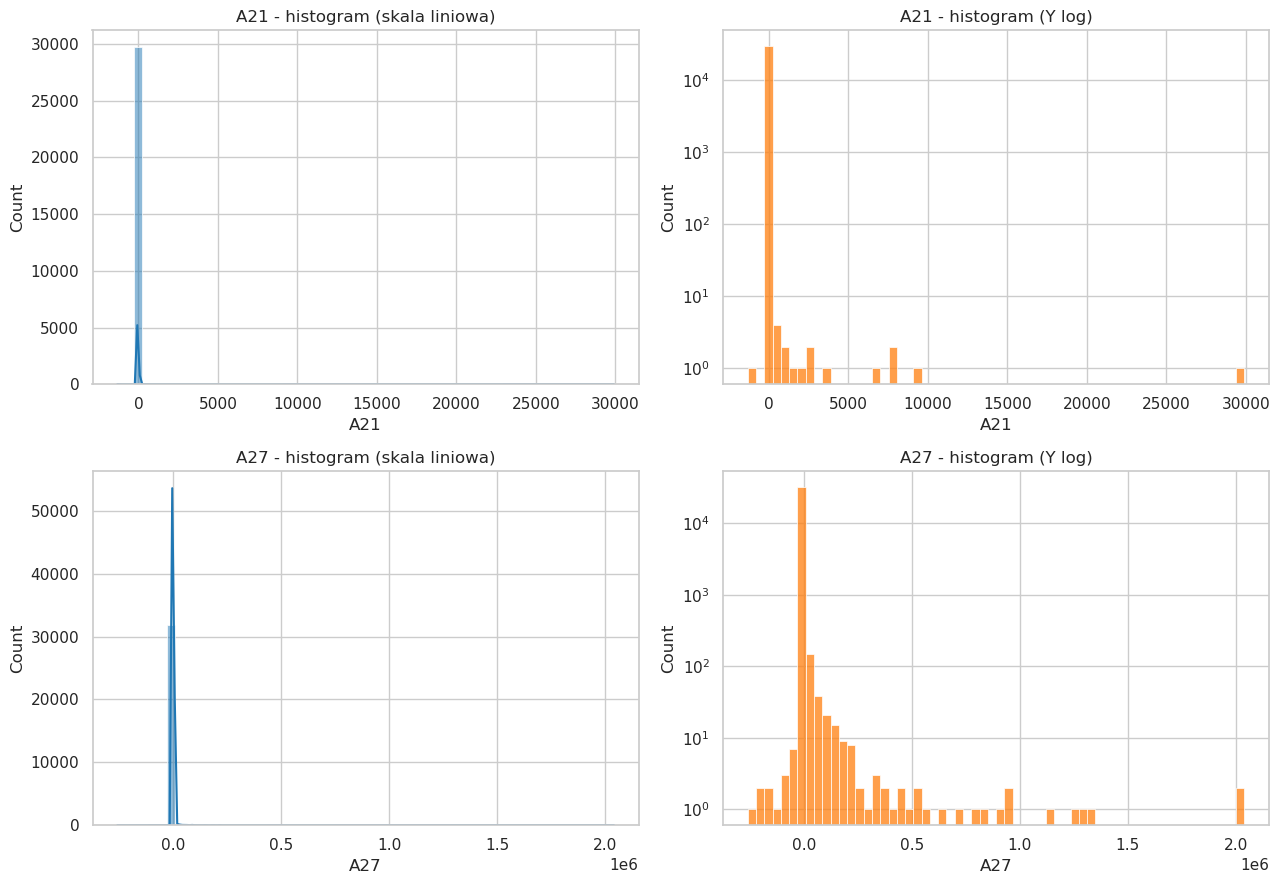

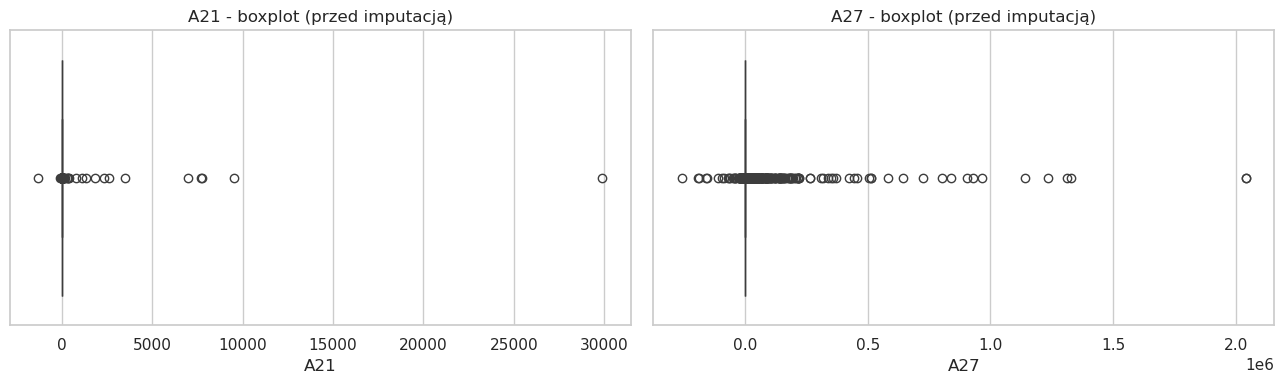

Wskazówka interpretacyjna: jeśli rozkład jest silnie skośny i z ciężkimi ogonami, mediana zwykle jest bezpieczniejsza niż średnia.


In [14]:
# Diagnostyka rozkładów A21/A27 PRZED imputacją (na train, aby uniknąć leakage)
plot_cols = ['A21', 'A27']
missing_plot_cols = [c for c in plot_cols if c not in X_train.columns]
if missing_plot_cols:
    raise ValueError(f"Brak kolumn do wizualizacji: {missing_plot_cols}")

plot_df = X_train[plot_cols].copy()

summary_rows = []
for col in plot_cols:
    s = plot_df[col]
    valid = s.dropna()
    summary_rows.append({
        'feature': col,
        'missing_%': round(s.isna().mean() * 100, 3),
        'n_non_missing': int(valid.shape[0]),
        'mean': float(valid.mean()) if len(valid) else np.nan,
        'median': float(valid.median()) if len(valid) else np.nan,
        'std': float(valid.std()) if len(valid) else np.nan,
        'skew': float(valid.skew()) if len(valid) else np.nan,
        'p01': float(valid.quantile(0.01)) if len(valid) else np.nan,
        'p25': float(valid.quantile(0.25)) if len(valid) else np.nan,
        'p50': float(valid.quantile(0.50)) if len(valid) else np.nan,
        'p75': float(valid.quantile(0.75)) if len(valid) else np.nan,
        'p99': float(valid.quantile(0.99)) if len(valid) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
print('Podsumowanie rozkładu przed imputacją (train only):')
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, col in enumerate(plot_cols):
    # Histogram na skali liniowej
    sns.histplot(plot_df[col], bins=60, kde=True, ax=axes[i, 0], color='#1f77b4')
    axes[i, 0].set_title(f'{col} - histogram (skala liniowa)')
    axes[i, 0].set_xlabel(col)

    # Histogram na skali logarytmicznej osi Y, żeby lepiej zobaczyć ogony
    sns.histplot(plot_df[col], bins=60, kde=False, ax=axes[i, 1], color='#ff7f0e')
    axes[i, 1].set_yscale('log')
    axes[i, 1].set_title(f'{col} - histogram (Y log)')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, col in enumerate(plot_cols):
    sns.boxplot(x=plot_df[col], ax=axes[i], color='#2ca02c')
    axes[i].set_title(f'{col} - boxplot (przed imputacją)')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

print('Wskazówka interpretacyjna: jeśli rozkład jest silnie skośny i z ciężkimi ogonami, mediana zwykle jest bezpieczniejsza niż średnia.')

## 4. Preprocessing bez leakage (fit na train, transform na test) + analiza outlierów

W tej sekcji uruchamiamy porównanie **3 strategii braków danych** i **3 strategii outlierów** (łącznie 9 kombinacji), każdorazowo z zachowaniem zasady anti-leakage.

Strategie missing-data:
- `m1_impute_all`: imputacja medianą we wszystkich kolumnach modelowych,
- `m2_drop_high_na_then_impute`: usunięcie wierszy o > 7 brakujących kolumnach,   usunięcie kolumn o wysokim NA (próg liczony na train), potem imputacja medianą,
- `m3_mechanistic_current`: obecne podejście mechanistyczne + imputacja medianą.

Strategie outlierów:
- `o1_baseline` (bez usuwania),
- `o2_winsorization_1_99` (klipowanie na q1 i q99)
- `o3_winsorization_iqr` (klipowanie na Q25 - 1,5 IQR i Q75 + 1,5 IQR)

Po porównaniu metryk wybieramy najlepszą konfigurację do dalszych sekcji (PCA, t-SNE i modele końcowe).

In [ ]:
# Eksperyment główny: 3 strategie braków danych x 3 strategie outlierów x 3 skalery (anti-leakage)
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, fbeta_score # DODANO fbeta_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np


def engineer_mechanistic_missingness(frame):
    """Tworzy cechy mechanistyczne analogiczne do obecnego rozwiązania."""
    out = frame.copy()
    required_cols = {'A21', 'A27', 'A37', 'A45', 'A53', 'A54', 'A59', 'A60', 'A64'}
    missing_required = sorted(required_cols - set(out.columns))
    if missing_required:
        raise KeyError(f'Brak wymaganych kolumn do mechanistycznego missingness: {missing_required}')

    a37_missing = out['A37'].isna()
    a59_zero = out['A59'].eq(0)
    out['A59_no_long_term_debt'] = a59_zero.astype(int)
    out['A37_struct_missing'] = (a37_missing & a59_zero).astype(int)
    out['A37_model'] = out['A37'].copy()
    out['A21_model'] = out['A21'].copy()
    out['A27_model'] = out['A27'].copy()
    out['A_inventory_missing_group'] = (out['A45'].isna() | out['A60'].isna()).astype(int)
    fixed_assets_cols = [c for c in ['A64', 'A53', 'A54', 'A28'] if c in out.columns]
    out['A_fixed_assets_missing_group'] = out[fixed_assets_cols].isna().all(axis=1).astype(int)

    return out


def build_feature_set(X_train_raw, X_test_raw, base_cols, missing_strategy, high_na_threshold=0.30):
    """Buduje train/test po strategii missing-data i zwraca szczegóły konfiguracji."""
    train_work = X_train_raw[base_cols].copy()
    test_work = X_test_raw[base_cols].copy()
    dropped_rows_count = 0

    if missing_strategy == 'm1_impute_all':
        pass

    elif missing_strategy == 'm2_drop_high_na_then_impute':
        na_ratio = train_work.isna().mean()
        dropped_cols = na_ratio[na_ratio > high_na_threshold].index.tolist()
        feature_cols = [c for c in base_cols if c not in dropped_cols]
        train_work = train_work[feature_cols].copy()
        test_work = test_work[feature_cols].copy()
        # Dodatkowy krok m2: usuwamy z train wiersze z >7 brakami
        row_missing_count_train = train_work.isna().sum(axis=1)
        keep_rows_mask = row_missing_count_train <= 7
        dropped_rows_count = int((~keep_rows_mask).sum())
        train_work = train_work.loc[keep_rows_mask].copy()

    elif missing_strategy == 'm3_mechanistic_current':
        train_work = engineer_mechanistic_missingness(train_work)
        test_work = engineer_mechanistic_missingness(test_work)

        feature_cols = [c for c in train_work.columns if c.startswith('A')] + [
            'years_to_prediction',
            'A59_no_long_term_debt',
            'A37_struct_missing',
            'A_inventory_missing_group',
            'A_fixed_assets_missing_group'
        ]
        feature_cols = [c for c in feature_cols if c not in {'A37', 'A21', 'A27'}]
        feature_cols = [c for c in feature_cols if c in train_work.columns]

        train_work = train_work[feature_cols].copy()
        test_work = test_work[feature_cols].copy()

    else:
        raise ValueError(f'Nieznana strategia missing-data: {missing_strategy}')

    imputer = SimpleImputer(strategy='median')
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(train_work), columns=train_work.columns, index=train_work.index
    )
    X_test_imputed = pd.DataFrame(
        imputer.transform(test_work), columns=test_work.columns, index=test_work.index
    )

    details = {
        'missing_strategy': missing_strategy,
        'n_features_before_model': len(train_work.columns),
        'feature_cols': list(train_work.columns),
        'high_na_threshold': high_na_threshold if missing_strategy == 'm2_drop_high_na_then_impute' else np.nan,
        'dropped_cols_count': len(set(base_cols) - set(train_work.columns)),
        'dropped_rows_count': dropped_rows_count
    }
    return X_train_imputed, X_test_imputed, details


def apply_outlier_strategy(X_train_df, X_test_df, outlier_strategy):
    """Zastępuje wartości skrajne (winsoryzacja) na podstawie rozkładu ze zbioru treningowego."""
    X_train_out = X_train_df.copy()
    X_test_out = X_test_df.copy()
    
    if outlier_strategy == 'o1_baseline':
        pass
        
    elif outlier_strategy == 'o2_winsorize_1_99':
        lower_bounds = X_train_out.quantile(0.01)
        upper_bounds = X_train_out.quantile(0.99)
        X_train_out = X_train_out.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
        X_test_out = X_test_out.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
        
    elif outlier_strategy == 'o3_winsorize_iqr':
        q1 = X_train_out.quantile(0.25)
        q3 = X_train_out.quantile(0.75)
        iqr = q3 - q1
        lower_bounds = q1 - 1.5 * iqr
        upper_bounds = q3 + 1.5 * iqr
        X_train_out = X_train_out.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
        X_test_out = X_test_out.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
        
    else:
        raise ValueError(f'Nieznana strategia outlierów: {outlier_strategy}')
        
    return X_train_out, X_test_out


def evaluate_binary(y_true, y_pred):
    """Ewaluuje model, DODANO metrykę f2 (beta=2)."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    # DODANO: Wyliczenie F2-score (Recall jest 2x ważniejszy)
    f2 = fbeta_score(y_true, y_pred, beta=2.0, average='binary', zero_division=0)
    
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'f2': float(f2) # Zwracamy f2 w słowniku
    }


def run_single_configuration(X_train_imp_df, X_test_imp_df, y_train, y_test, outlier_strategy, scaler_strategy):
    """Uruchamia transformację outlierów (winsoryzacja) + skalowanie + RF + LR dla jednej konfiguracji."""
    
    X_train_clean_local, X_test_clean_local = apply_outlier_strategy(
        X_train_imp_df, X_test_imp_df, outlier_strategy
    )
    
    kept_rows = len(X_train_clean_local)
    removed_rows = 0

    y_train_clean_local = y_train.loc[X_train_clean_local.index].copy()
    y_test_clean_local = y_test.loc[X_test_clean_local.index].copy()

    if scaler_strategy == 's1_standard':
        scaler = StandardScaler()
    elif scaler_strategy == 's2_minmax':
        scaler = MinMaxScaler()
    elif scaler_strategy == 's3_robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f'Nieznana strategia skalowania: {scaler_strategy}')

    X_train_scaled_local = scaler.fit_transform(X_train_clean_local)
    X_test_scaled_local = scaler.transform(X_test_clean_local)

    rf_model = RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight='balanced_subsample', n_jobs=-1
    )
    rf_model.fit(X_train_scaled_local, y_train_clean_local)
    y_pred_rf = rf_model.predict(X_test_scaled_local)
    rf_metrics = evaluate_binary(y_test_clean_local, y_pred_rf)

    lr_model = LogisticRegression(
        solver='saga', max_iter=5000, tol=1e-3, class_weight='balanced', random_state=42
    )
    lr_model.fit(X_train_scaled_local, y_train_clean_local)
    y_pred_lr = lr_model.predict(X_test_scaled_local)
    lr_metrics = evaluate_binary(y_test_clean_local, y_pred_lr)

    results = {
        'train_rows_kept': kept_rows,
        'train_rows_removed': removed_rows,
        'rf_metrics': rf_metrics,
        'lr_metrics': lr_metrics,
        # ZMIANA: Decyzję o zwycięzcy podejmujemy na podstawie F2, a nie F1
        'best_model_f2': max(rf_metrics['f2'], lr_metrics['f2']),
        'best_model_name': 'RandomForest' if rf_metrics['f2'] >= lr_metrics['f2'] else 'LogisticRegression'
    }

    artifacts = {
        'X_train_clean': X_train_clean_local,
        'X_test_clean': X_test_clean_local,
        'y_train_clean': y_train_clean_local,
        'y_test_clean': y_test_clean_local,
        'X_train_scaled': X_train_scaled_local,
        'X_test_scaled': X_test_scaled_local
    }
    
    return results, artifacts

def run_preprocessing_experiment(X_train, X_test, y_train, y_test):
    """Wykonuje pełny benchmark 3x3x3 i zwraca tabelę wyników posortowaną po F2-score."""
    a_cols = [c for c in X_train.columns if c.startswith('A')]
    base_cols = a_cols + ['years_to_prediction']

    missing_strategies = ['m1_impute_all', 'm2_drop_high_na_then_impute', 'm3_mechanistic_current']
    outlier_strategies = ['o1_baseline', 'o2_winsorize_1_99', 'o3_winsorize_iqr']
    scaler_strategies = ['s1_standard', 's2_minmax', 's3_robust']

    experiment_rows = []
    prepared_configs = {}

    for m_strategy in missing_strategies:
        X_train_imp_df, X_test_imp_df, prep_details = build_feature_set(
            X_train, X_test, base_cols=base_cols, missing_strategy=m_strategy, high_na_threshold=0.30
        )

        for o_strategy in outlier_strategies:
            for s_strategy in scaler_strategies:
                combo_id = f'{m_strategy}__{o_strategy}__{s_strategy}'
                combo_results, combo_artifacts = run_single_configuration(
                    X_train_imp_df, X_test_imp_df, y_train, y_test, 
                    outlier_strategy=o_strategy, 
                    scaler_strategy=s_strategy
                )

                prepared_configs[combo_id] = {
                    **combo_artifacts,
                    'feature_cols': prep_details['feature_cols'],
                    'missing_strategy': m_strategy,
                    'outlier_strategy': o_strategy,
                    'scaler_strategy': s_strategy
                }

                rf_metrics = combo_results['rf_metrics']
                lr_metrics = combo_results['lr_metrics']
                experiment_rows.append({
                    'combo_id': combo_id,
                    'missing_strategy': m_strategy,
                    'outlier_strategy': o_strategy,
                    'scaler_strategy': s_strategy,
                    'n_features': prep_details['n_features_before_model'],
                    'dropped_cols_count': prep_details['dropped_cols_count'],
                    'high_na_threshold': prep_details['high_na_threshold'],
                    'train_rows_kept': combo_results['train_rows_kept'],
                    'train_rows_removed': combo_results['train_rows_removed'],
                    'rf_accuracy': round(rf_metrics['accuracy'], 4),
                    'rf_precision': round(rf_metrics['precision'], 4),
                    'rf_recall': round(rf_metrics['recall'], 4),
                    'rf_f1': round(rf_metrics['f1'], 4),
                    'rf_f2': round(rf_metrics['f2'], 4), # DODANO zapisywanie F2
                    'lr_accuracy': round(lr_metrics['accuracy'], 4),
                    'lr_precision': round(lr_metrics['precision'], 4),
                    'lr_recall': round(lr_metrics['recall'], 4),
                    'lr_f1': round(lr_metrics['f1'], 4),
                    'lr_f2': round(lr_metrics['f2'], 4), # DODANO zapisywanie F2
                    'best_model_f2': round(combo_results['best_model_f2'], 4), # ZMIANA
                    'best_model_name': combo_results['best_model_name']
                })

    # ZMIANA: Sortujemy całą tabelę eksperymentu na podstawie F2-Score z uwzględnieniem f1 w przypadku remisów
    experiment_df_local = pd.DataFrame(experiment_rows).sort_values(
        by=['best_model_f2', 'best_model_name'], ascending=[False, True]
    ).reset_index(drop=True)

    return experiment_df_local, prepared_configs

# ---- Uruchomienie benchmarku 3x3x3 ----
experiment_df, prepared_configs = run_preprocessing_experiment(X_train, X_test, y_train, y_test)

print('Porównanie 3x3x3 (missing-data x outliery x skalery) zakończone:')
display(experiment_df)

# Wybór najlepszej konfiguracji do dalszych sekcji notebooka (teraz zależy on od F2)
best_combo = experiment_df.iloc[0]['combo_id']
best_cfg = prepared_configs[best_combo]

selected_missing_strategy = best_cfg['missing_strategy']
selected_outlier_variant = best_cfg['outlier_strategy']
selected_scaler_variant = best_cfg['scaler_strategy']

X_train_clean = best_cfg['X_train_clean'].reset_index(drop=True)
X_test_clean = best_cfg['X_test_clean'].reset_index(drop=True)
y_train_model = best_cfg['y_train_clean'].reset_index(drop=True)
y_test_model = best_cfg['y_test_clean'].reset_index(drop=True)

# Finalne dane do PCA, t-SNE i modeli końcowych
X_train_scaled = best_cfg['X_train_scaled']
X_test_scaled = best_cfg['X_test_scaled']

print('\nWybrana najlepsza konfiguracja do dalszego pipeline (wg F2-score):')
print(f"- combo_id: {best_combo}")
print(f"- missing strategy: {selected_missing_strategy}")
print(f"- outlier strategy: {selected_outlier_variant}")
print(f"- scaler strategy:  {selected_scaler_variant}")
print(f"- X_train_scaled shape: {X_train_scaled.shape}")
print(f"- X_test_scaled shape:  {X_test_scaled.shape}")

/home/dominik/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dominik/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dominik/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dominik/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dominik/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Porównanie 3x3x3 (missing-data x outliery x skalery) zakończone:


,combo_id,missing_strategy,outlier_strategy,scaler_strategy,n_features,dropped_cols_count,high_na_threshold,train_rows_kept,train_rows_removed,rf_accuracy,...,rf_recall,rf_f1,rf_f2,lr_accuracy,lr_precision,lr_recall,lr_f1,lr_f2,best_model_f2,best_model_name
0,m1_impute_all__o3_winsorize_iqr__s1_standard,m1_impute_all,o3_winsorize_iqr,s1_standard,72,0,NaN,34403,0,0.9637,...,0.2950,0.4409,0.3400,0.7607,0.1355,0.7314,0.2286,0.3891,0.3891,LogisticRegression
1,m2_drop_high_na_then_impute__o3_winsorize_iqr_...,m2_drop_high_na_then_impute,o3_winsorize_iqr,s3_robust,70,2,0.3,34044,0,0.9637,...,0.2950,0.4409,0.3400,0.7440,0.1310,0.7602,0.2236,0.3878,0.3878,LogisticRegression
2,m1_impute_all__o3_winsorize_iqr__s3_robust,m1_impute_all,o3_winsorize_iqr,s3_robust,72,0,NaN,34403,0,0.9637,...,0.2950,0.4409,0.3400,0.7434,0.1308,0.7602,0.2232,0.3873,0.3873,LogisticRegression
3,m3_mechanistic_current__o3_winsorize_iqr__s3_r...,m3_mechanistic_current,o3_winsorize_iqr,s3_robust,73,3,NaN,34403,0,0.9608,...,0.2374,0.3701,0.2772,0.7446,0.1304,0.7530,0.2223,0.3852,0.3852,LogisticRegression
4,m1_impute_all__o3_winsorize_iqr__s2_minmax,m1_impute_all,o3_winsorize_iqr,s2_minmax,72,0,NaN,34403,0,0.9634,...,0.2878,0.4324,0.3322,0.7341,0.1263,0.7578,0.2165,0.3789,0.3789,LogisticRegression
5,m3_mechanistic_current__o3_winsorize_iqr__s2_m...,m3_mechanistic_current,o3_winsorize_iqr,s2_minmax,73,3,NaN,34403,0,0.9607,...,0.2302,0.3623,0.2695,0.7340,0.1262,0.7578,0.2164,0.3788,0.3788,LogisticRegression
6,m2_drop_high_na_then_impute__o3_winsorize_iqr_...,m2_drop_high_na_then_impute,o3_winsorize_iqr,s1_standard,70,2,0.3,34044,0,0.9638,...,0.2974,0.4436,0.3425,0.7708,0.1349,0.6882,0.2255,0.3780,0.3780,LogisticRegression
7,m2_drop_high_na_then_impute__o3_winsorize_iqr_...,m2_drop_high_na_then_impute,o3_winsorize_iqr,s2_minmax,70,2,0.3,34044,0,0.9638,...,0.2950,0.4417,0.3402,0.7326,0.1256,0.7578,0.2156,0.3777,0.3777,LogisticRegression
8,m2_drop_high_na_then_impute__o2_winsorize_1_99...,m2_drop_high_na_then_impute,o2_winsorize_1_99,s1_standard,70,2,0.3,34044,0,0.9641,...,0.3022,0.4492,0.3477,0.7426,0.1267,0.7314,0.2160,0.3742,0.3742,LogisticRegression
9,m1_impute_all__o2_winsorize_1_99__s1_standard,m1_impute_all,o2_winsorize_1_99,s1_standard,72,0,NaN,34403,0,0.9643,...,0.3046,0.4528,0.3504,0.7396,0.1229,0.7122,0.2096,0.3635,0.3635,LogisticRegression



Wybrana najlepsza konfiguracja do dalszego pipeline (wg F2-score):
- combo_id: m1_impute_all__o3_winsorize_iqr__s1_standard
- missing strategy: m1_impute_all
- outlier strategy: o3_winsorize_iqr
- scaler strategy:  s1_standard
- X_train_scaled shape: (34403, 72)
- X_test_scaled shape:  (8601, 72)


## 5. Redukcja wymiarów: PCA i t-SNE

Realizujemy oba algorytmy z instrukcji. PCA jest metodą liniową i pozwala monitorować wyjaśnioną wariancję, a t-SNE pokazuje lokalną strukturę klastrów (na podpróbce train ze względu na złożoność).

PCA variance explained: PC1=0.349, PC2=0.132, SUM=0.481

Największy wpływ na PC1 (Top 5 atrybutów):
 - A12 (gross profit / short-term liabilities): 0.1784
 - A14 ((gross profit + interest) / total assets): 0.1745
 - A7 (EBIT / total assets): 0.1745
 - A18 (gross profit / total assets): 0.1745
 - A16 ((gross profit + depreciation) / total liabilities): 0.1733

Największy wpływ na PC2 (Top 5 atrybutów):
 - A17 (total assets / total liabilities): 0.1867
 - A8 (book value of equity / total liabilities): 0.1863
 - A4 (current assets / short-term liabilities): 0.1859
 - A50 (current assets / total liabilities): 0.1854
 - A33 (operating expenses / short-term liabilities): 0.1766
--------------------------------------------------


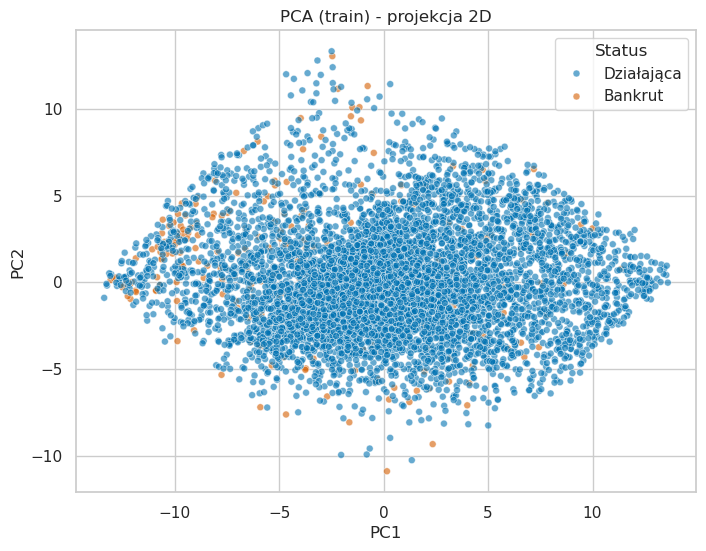

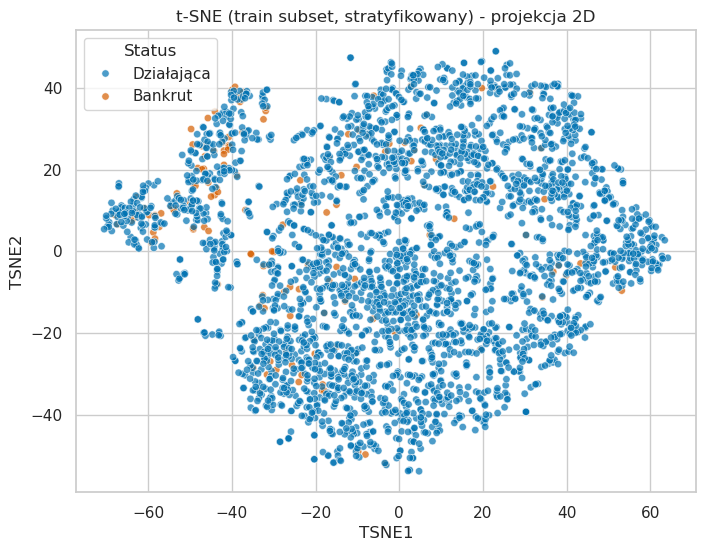

In [31]:
from sklearn.model_selection import train_test_split

# Opcjonalne: upewnienie się, że y jest resetowane (zabezpieczenie przed błędami indexów)
y_train_plot = y_train_model.reset_index(drop=True) if 'y_train_model' in globals() else y_train.reset_index(drop=True)

status_map = {0: 'Działająca', 1: 'Bankrut'}
status_palette = {'Działająca': '#0072B2', 'Bankrut': '#D55E00'}
hue_order = ['Działająca', 'Bankrut']

# ----------------- PCA -----------------
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled) # Przekształcenie testowego bez fitowania!

pca_df = pd.DataFrame(X_train_pca_2d, columns=['PC1', 'PC2'])
pca_df['status'] = y_train_plot.map(status_map).fillna('Nieznany')

# Sortowanie, by pomarańczowe kropki (Bankrut) rysowały się NA WIERZCHU
pca_df_plot = pca_df.sample(min(len(pca_df), 7000), random_state=42)
pca_df_plot = pca_df_plot.sort_values(by='status') 

explained = pca_2d.explained_variance_ratio_
print(f'PCA variance explained: PC1={explained[0]:.3f}, PC2={explained[1]:.3f}, SUM={explained.sum():.3f}')

# -------- NOWE: Analiza wpływu atrybutów na PC1 i PC2 --------
# Pobieramy nazwy kolumn z X_train_clean (przed skalowaniem to był DataFrame)
feature_names = X_train_clean.columns 

feature_mapping_local = feature_mapping if 'feature_mapping' in globals() else {}

def format_feature_label(feature_code):
    feature_desc = feature_mapping_local.get(feature_code, feature_code)
    if feature_desc != feature_code:
        return f"{feature_code} ({feature_desc})"
    return str(feature_code)

# PCA components_ to macierz o wymiarach (n_components, n_features)
loadings_pc1 = pd.Series(pca_2d.components_[0], index=feature_names)
loadings_pc2 = pd.Series(pca_2d.components_[1], index=feature_names)

# Pobieramy 5 atrybutów o największej WARTOŚCI BEZWZGLĘDNEJ wagi dla PC1
top_pc1_features = loadings_pc1.abs().sort_values(ascending=False).head(5).index
print("\nNajwiększy wpływ na PC1 (Top 5 atrybutów):")
for feat in top_pc1_features:
    print(f" - {format_feature_label(feat)}: {loadings_pc1[feat]:.4f}")

# Pobieramy 5 atrybutów o największej WARTOŚCI BEZWZGLĘDNEJ wagi dla PC2
top_pc2_features = loadings_pc2.abs().sort_values(ascending=False).head(5).index
print("\nNajwiększy wpływ na PC2 (Top 5 atrybutów):")
for feat in top_pc2_features:
    print(f" - {format_feature_label(feat)}: {loadings_pc2[feat]:.4f}")
print("-" * 50)
# -------------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df_plot,
    x='PC1',
    y='PC2',
    hue='status',
    hue_order=hue_order,
    palette=status_palette,
    alpha=0.6,
    s=25,
    linewidth=0.5 # Delikatna obwódka pomaga odróżnić nałożone na siebie punkty
)
plt.title('PCA (train) - projekcja 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Status')
plt.show()

# ----------------- t-SNE -----------------
# Stratyfikowane losowanie podpróbki do t-SNE (zachowuje ~5% bankrutów)
tsne_sample_size = min(3000, X_train_scaled.shape[0])

# Używamy train_test_split jako tricku do stratified sampling
X_tsne_subset, _, y_tsne_subset, _ = train_test_split(
    X_train_scaled, 
    y_train_plot, 
    train_size=tsne_sample_size, 
    stratify=y_train_plot, # KLUCZOWE: Zachowanie balansu klas!
    random_state=42
)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne_2d = tsne.fit_transform(X_tsne_subset)

tsne_df = pd.DataFrame(X_tsne_2d, columns=['TSNE1', 'TSNE2'])
# Musimy użyć reset_index na podpróbce y, bo zrobiliśmy na niej split
tsne_df['status'] = y_tsne_subset.reset_index(drop=True).map(status_map).fillna('Nieznany')

# Ponownie: sortujemy, aby bankruci byli rysowani jako ostatni (na wierzchu)
tsne_df = tsne_df.sort_values(by='status')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='status',
    hue_order=hue_order,
    palette=status_palette,
    alpha=0.7,
    s=28,
    linewidth=0.5
)
plt.title('t-SNE (train subset, stratyfikowany) - projekcja 2D')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.legend(title='Status')
plt.show()

## 6. Modelowanie i ewaluacja (2 klasyfikatory)

Trenujemy dwa modele wymagane w zadaniu: **Random Forest** i **Logistic Regression**. Oba modele uczymy na tych samych danych po imputacji i skalowaniu wyfitowanym wyłącznie na zbiorze treningowym.

Porównanie modeli na zbiorze testowym:


/home/dominik/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model,accuracy,precision,recall,f1,f2
0,LogisticRegression,0.7607,0.1355,0.7314,0.2286,0.3891
1,RandomForest,0.9637,0.8723,0.2950,0.4409,0.3400



=== RandomForest: classification_report ===
              precision    recall  f1-score   support

           0     0.9652    0.9978    0.9813      8184
           1     0.8723    0.2950    0.4409       417

    accuracy                         0.9637      8601
   macro avg     0.9188    0.6464    0.7111      8601
weighted avg     0.9607    0.9637    0.9551      8601

=== LogisticRegression: classification_report ===
              precision    recall  f1-score   support

           0     0.9824    0.7622    0.8584      8184
           1     0.1355    0.7314    0.2286       417

    accuracy                         0.7607      8601
   macro avg     0.5589    0.7468    0.5435      8601
weighted avg     0.9413    0.7607    0.8279      8601



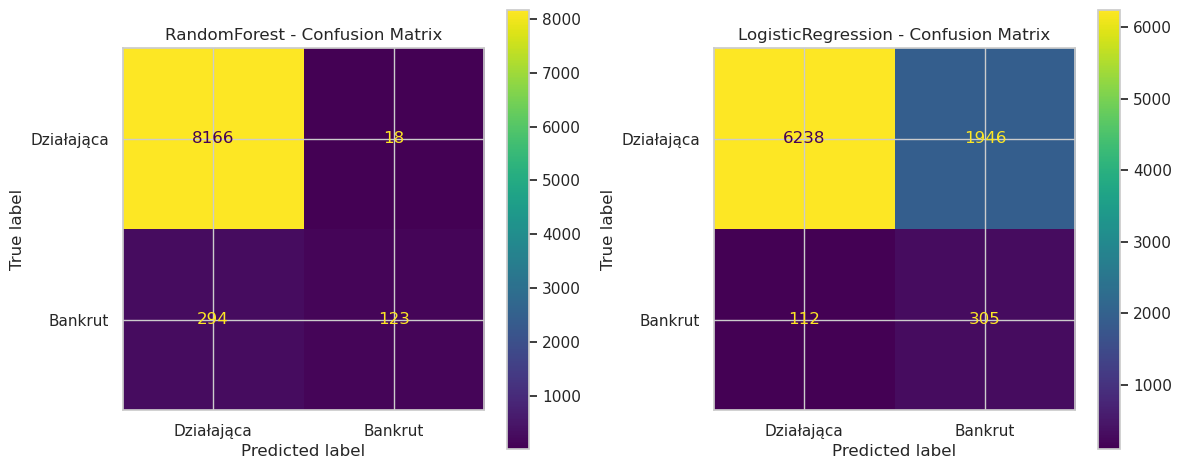

In [34]:
# Modele klasyfikacyjne (2 wymagane przez assignment): RF i LR
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, fbeta_score # DODANO fbeta_score

y_train_eval = y_train_model if 'y_train_model' in globals() else y_train.reset_index(drop=True)
y_test_eval = y_test_model if 'y_test_model' in globals() else y_test.reset_index(drop=True)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train_eval)
y_pred_rf = rf_model.predict(X_test_scaled)

# Dla LR używamy solvera SAGA, który stabilniej zbiega dla większych zbiorów
lr_model = LogisticRegression(
    solver='saga',
    max_iter=5000,
    tol=1e-3,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train_eval)
y_pred_lr = lr_model.predict(X_test_scaled)

def _metrics_row(model_name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    # DODANO: Wyliczenie F2-score
    f2 = fbeta_score(y_true, y_pred, beta=2.0, average='binary', zero_division=0)
    
    return {
        'model': model_name,
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'f2': round(f2, 4) # DODANO do słownika
    }

# ZMIANA: Sortowanie wyników po F2 zamiast F1
results_df = pd.DataFrame([
    _metrics_row('RandomForest', y_test_eval, y_pred_rf),
    _metrics_row('LogisticRegression', y_test_eval, y_pred_lr)
]).sort_values(by='f2', ascending=False).reset_index(drop=True)

print('Porównanie modeli na zbiorze testowym:')
display(results_df)

print('\n=== RandomForest: classification_report ===')
print(classification_report(y_test_eval, y_pred_rf, digits=4))

print('=== LogisticRegression: classification_report ===')
print(classification_report(y_test_eval, y_pred_lr, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_eval, y_pred_rf, display_labels=['Działająca', 'Bankrut'], ax=axes[0], values_format='d'
)
axes[0].set_title('RandomForest - Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test_eval, y_pred_lr, display_labels=['Działająca', 'Bankrut'], ax=axes[1], values_format='d'
)
axes[1].set_title('LogisticRegression - Confusion Matrix')

plt.tight_layout()
plt.show()

### Side quest: czy starania poszły na marne?

Trenowanie modeli dla konfiguracji: m3_mechanistic_current__o3_winsorize_iqr__s3_robust



,model,accuracy,precision,recall,f1,f2
0,LogisticRegression (M3 Mechanistic),0.7446,0.1304,0.7530,0.2223,0.3852
1,RandomForest (M3 Mechanistic),0.9608,0.8390,0.2374,0.3701,0.2772



=== RandomForest (M3): classification_report ===
              precision    recall  f1-score   support

           0     0.9625    0.9977    0.9798      8184
           1     0.8390    0.2374    0.3701       417

    accuracy                         0.9608      8601
   macro avg     0.9007    0.6175    0.6749      8601
weighted avg     0.9565    0.9608    0.9502      8601

=== LogisticRegression (M3): classification_report ===
              precision    recall  f1-score   support

           0     0.9834    0.7441    0.8472      8184
           1     0.1304    0.7530    0.2223       417

    accuracy                         0.7446      8601
   macro avg     0.5569    0.7486    0.5347      8601
weighted avg     0.9420    0.7446    0.8169      8601



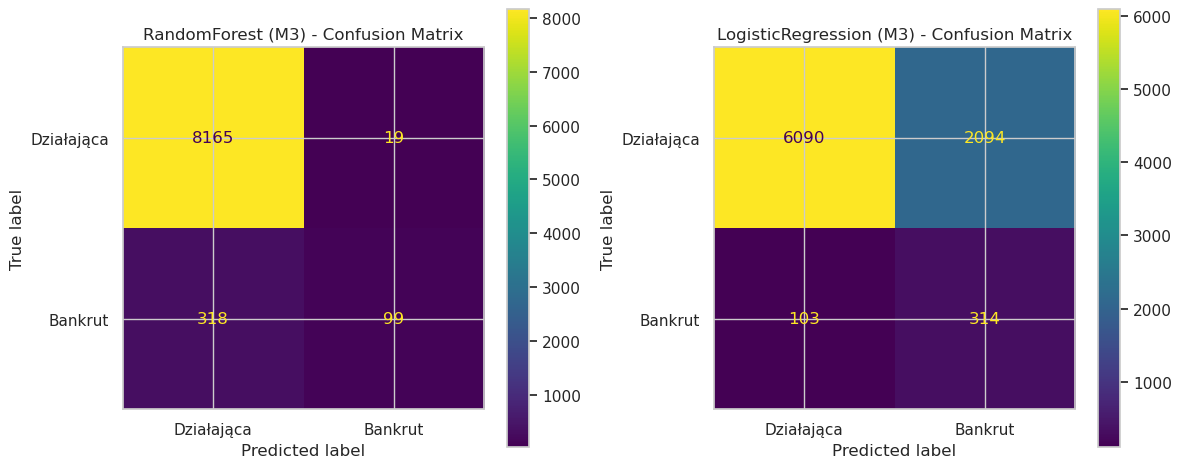

In [35]:
# --- Sprawdzenie konkretnej, wybranej konfiguracji autorskiej ---
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, fbeta_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# 1. Wyciągnięcie danych z naszego słownika po nazwie combo_id
target_combo = 'm3_mechanistic_current__o3_winsorize_iqr__s3_robust'

print(f"Trenowanie modeli dla konfiguracji: {target_combo}\n")

custom_cfg = prepared_configs[target_combo]

X_train_custom = custom_cfg['X_train_scaled']
X_test_custom = custom_cfg['X_test_scaled']
y_train_custom = custom_cfg['y_train_clean'].reset_index(drop=True)
y_test_custom = custom_cfg['y_test_clean'].reset_index(drop=True)

# 2. Trening RandomForest
rf_custom = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf_custom.fit(X_train_custom, y_train_custom)
y_pred_rf_custom = rf_custom.predict(X_test_custom)

# 3. Trening LogisticRegression
lr_custom = LogisticRegression(
    solver='saga',
    max_iter=5000,
    tol=1e-3,
    class_weight='balanced',
    random_state=42
)
lr_custom.fit(X_train_custom, y_train_custom)
y_pred_lr_custom = lr_custom.predict(X_test_custom)

# 4. Funkcja ewaluacyjna
def _metrics_row(model_name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2.0, average='binary', zero_division=0)
    
    return {
        'model': model_name,
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'f2': round(f2, 4)
    }

# 5. Podsumowanie wyników
results_custom_df = pd.DataFrame([
    _metrics_row('RandomForest (M3 Mechanistic)', y_test_custom, y_pred_rf_custom),
    _metrics_row('LogisticRegression (M3 Mechanistic)', y_test_custom, y_pred_lr_custom)
]).sort_values(by='f2', ascending=False).reset_index(drop=True)

display(results_custom_df)

print('\n=== RandomForest (M3): classification_report ===')
print(classification_report(y_test_custom, y_pred_rf_custom, digits=4))

print('=== LogisticRegression (M3): classification_report ===')
print(classification_report(y_test_custom, y_pred_lr_custom, digits=4))

# 6. Wizualizacja Macierzy Błędów
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_custom, y_pred_rf_custom, display_labels=['Działająca', 'Bankrut'], ax=axes[0], values_format='d'
)
axes[0].set_title('RandomForest (M3) - Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test_custom, y_pred_lr_custom, display_labels=['Działająca', 'Bankrut'], ax=axes[1], values_format='d'
)
axes[1].set_title('LogisticRegression (M3) - Confusion Matrix')

plt.tight_layout()
plt.show()

### Appendix A: Próba odtworzenia braków na podstawie zależności między atrybutami

Poniższa sekcja ma charakter rozszerzony. Główna ścieżka raportu (pod assignment) znajduje się wyżej i zachowuje standardowy pipeline ML bez leakage.

In [ ]:
# Walidacja relacji exact-candidates i imputacja (tylko pass)
from pathlib import Path
import json

relations_path_candidates = [
    Path('exact_candidate_relations.json'),
    Path('notebooks/lab2/exact_candidate_relations.json')
]
relations_path = next((p for p in relations_path_candidates if p.exists()), None)
if relations_path is None:
    raise FileNotFoundError('Nie znaleziono exact_candidate_relations.json')

with open(relations_path, 'r', encoding='utf-8') as f:
    relations_payload = json.load(f)

strict_thresholds = relations_payload['strict_thresholds']
candidate_relations = relations_payload['relations']

feature_cols = [c for c in df.columns if c.startswith('A')]
work_df = df[feature_cols].copy()

def _guard_mask(frame, guards):
    mask = pd.Series(True, index=frame.index)
    for guard in guards:
        if guard.get('type') == 'nonzero':
            attr = guard['attr']
            eps = float(guard.get('eps', 1e-12))
            mask &= frame[attr].notna() & (frame[attr].abs() > eps)
    return mask

def _predict_relation(frame, relation):
    inputs = relation['inputs']
    op = relation['operation']

    base_mask = pd.Series(True, index=frame.index)
    for col in inputs:
        base_mask &= frame[col].notna()
    base_mask &= _guard_mask(frame, relation.get('guards', []))

    pred = pd.Series(np.nan, index=frame.index, dtype=float)
    if op == 'mul':
        pred.loc[base_mask] = frame.loc[base_mask, inputs[0]] * frame.loc[base_mask, inputs[1]]
    elif op == 'reciprocal':
        pred.loc[base_mask] = 1.0 / frame.loc[base_mask, inputs[0]]
    elif op == 'const_div':
        const = float(relation['const'])
        pred.loc[base_mask] = const / frame.loc[base_mask, inputs[0]]
    elif op == 'div':
        pred.loc[base_mask] = frame.loc[base_mask, inputs[0]] / frame.loc[base_mask, inputs[1]]
    elif op == 'one_minus':
        pred.loc[base_mask] = 1.0 - frame.loc[base_mask, inputs[0]]
    else:
        raise ValueError(f'Nieobsługiwana operacja: {op}')

    return pred, base_mask

validation_rows = []
for rel in candidate_relations:
    target = rel['target_attr']
    pred, base_mask = _predict_relation(work_df, rel)

    known_target_mask = work_df[target].notna()
    eval_mask = base_mask & known_target_mask
    known_count = int(known_target_mask.sum())
    eval_count = int(eval_mask.sum())

    if eval_count == 0 or known_count == 0:
        metrics = {
            'mae': np.nan,
            'median_mape_pct': np.nan,
            'p95_mape_pct': np.nan,
            'r2': np.nan,
            'coverage_pct': 0.0,
            'imputable_missing_count': int((base_mask & work_df[target].isna()).sum())
        }
    else:
        y_true = work_df.loc[eval_mask, target].astype(float)
        y_pred = pred.loc[eval_mask].astype(float)
        abs_err = (y_true - y_pred).abs()
        denom = y_true.abs().clip(lower=1e-9)
        mape_pct = (abs_err / denom) * 100

        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        r2_val = np.nan if ss_tot == 0 else float(1 - ss_res / ss_tot)

        metrics = {
            'mae': float(abs_err.mean()),
            'median_mape_pct': float(mape_pct.median()),
            'p95_mape_pct': float(mape_pct.quantile(0.95)),
            'r2': r2_val,
            'coverage_pct': float(eval_count / known_count * 100),
            'imputable_missing_count': int((base_mask & work_df[target].isna()).sum())
        }

    is_pass = (
        pd.notna(metrics['median_mape_pct'])
        and pd.notna(metrics['p95_mape_pct'])
        and metrics['median_mape_pct'] <= strict_thresholds['median_mape_pct_max']
        and metrics['p95_mape_pct'] <= strict_thresholds['p95_mape_pct_max']
        and metrics['coverage_pct'] >= strict_thresholds['coverage_pct_min']
    )

    validation_rows.append({
        'relation_id': rel['id'],
        'target_attr': target,
        'operation': rel['operation'],
        'inputs': ', '.join(rel['inputs']),
        'priority': int(rel.get('priority', 999)),
        'coverage_pct': round(metrics['coverage_pct'], 3),
        'median_mape_pct': round(metrics['median_mape_pct'], 6) if pd.notna(metrics['median_mape_pct']) else np.nan,
        'p95_mape_pct': round(metrics['p95_mape_pct'], 6) if pd.notna(metrics['p95_mape_pct']) else np.nan,
        'mae': round(metrics['mae'], 10) if pd.notna(metrics['mae']) else np.nan,
        'r2': round(metrics['r2'], 6) if pd.notna(metrics['r2']) else np.nan,
        'imputable_missing_count': int(metrics['imputable_missing_count']),
        'pass': bool(is_pass),
        'notes': rel.get('notes', '')
    })

validation_df = pd.DataFrame(validation_rows).sort_values(
    by=['pass', 'target_attr', 'priority', 'median_mape_pct'],
    ascending=[False, True, True, True]
).reset_index(drop=True)

print('Wyniki walidacji relacji exact-candidates:')
display(validation_df)

validation_payload = {
    'relations_file': str(relations_path),
    'strict_thresholds': strict_thresholds,
    'summary': {
        'n_candidates': int(len(validation_df)),
        'n_pass': int(validation_df['pass'].sum()),
        'n_fail': int((~validation_df['pass']).sum())
    },
    'results': validation_df.to_dict(orient='records')
}

validation_out_path = relations_path.parent / 'exact_candidate_validation.json'
with open(validation_out_path, 'w', encoding='utf-8') as f:
    json.dump(validation_payload, f, ensure_ascii=False, indent=2)

print(f'\nZapisano walidację do: {validation_out_path}')

# Imputacja relacyjna: tylko pass
pass_df = validation_df[validation_df['pass']].copy()
df_exact_imputed = df.copy()
imputation_log = []

if pass_df.empty:
    print('\nBrak relacji spełniających próg surowy - imputacja relacyjna pominięta.')
else:
    pass_rel_ids = set(pass_df['relation_id'])
    relation_map = {r['id']: r for r in candidate_relations if r['id'] in pass_rel_ids}

    for target_attr in sorted(pass_df['target_attr'].unique()):
        candidates = pass_df[pass_df['target_attr'] == target_attr].sort_values(
            by=['priority', 'p95_mape_pct', 'median_mape_pct']
        )

        target_missing_before = int(df_exact_imputed[target_attr].isna().sum())
        total_filled_for_target = 0

        for _, row in candidates.iterrows():
            rel = relation_map[row['relation_id']]
            pred, base_mask = _predict_relation(df_exact_imputed[feature_cols], rel)

            fill_mask = df_exact_imputed[target_attr].isna() & base_mask & pred.notna()
            fill_count = int(fill_mask.sum())

            if fill_count > 0:
                df_exact_imputed.loc[fill_mask, target_attr] = pred.loc[fill_mask]
                total_filled_for_target += fill_count
                imputation_log.append({
                    'relation_id': rel['id'],
                    'target_attr': target_attr,
                    'filled_count': fill_count
                })

        target_missing_after = int(df_exact_imputed[target_attr].isna().sum())
        print(
            f"{target_attr}: braki przed={target_missing_before}, "
            f"uzupełniono={total_filled_for_target}, po={target_missing_after}"
        )

    imputation_log_df = pd.DataFrame(imputation_log) if imputation_log else pd.DataFrame(
        columns=['relation_id', 'target_attr', 'filled_count']
    )
    print('\nLog imputacji relacyjnej (tylko pass):')
    display(imputation_log_df.groupby(['target_attr', 'relation_id'], as_index=False)['filled_count'].sum())

    total_missing_before = int(df[feature_cols].isna().sum().sum())
    total_missing_after = int(df_exact_imputed[feature_cols].isna().sum().sum())
    print(f"\nGlobalnie: braki przed={total_missing_before}, po={total_missing_after}, "
          f"uzupełniono={total_missing_before - total_missing_after}")

Wyniki walidacji relacji exact-candidates:


,relation_id,target_attr,operation,inputs,priority,coverage_pct,median_mape_pct,p95_mape_pct,mae,r2,imputable_missing_count,pass,notes
0,AUTO_A12_from_A18_A51_div,A12,div,"A18, A51",3,99.993,0.001464,0.004717,0.011216,0.999718,0,True,Auto inverse of R12_A18_from_A12_A51: A12 = A1...
1,AUTO_A15_from_A16_const_div_365_0,A15,const_div,A16,2,99.852,0.000997,0.004176,17.884809,0.999364,0,True,Auto inverse of R02_A16_from_A15: A15 = 365.0 ...
2,R02_A16_from_A15,A16,const_div,A15,1,99.988,0.000997,0.004176,0.020459,0.999035,0,True,A16 = 365 / A15
3,R01_A17_from_A2,A17,reciprocal,A2,1,99.993,0.001398,0.003518,0.005628,0.999999,0,True,A17 = total assets / total liabilities = 1 / A2
4,R12_A18_from_A12_A51,A18,mul,"A12, A51",2,99.703,0.001464,0.004717,0.005105,0.983104,0,True,A18 = A12 * A51
5,AUTO_A2_from_A17_reciprocal,A2,reciprocal,A17,2,99.795,0.001398,0.003518,0.032212,0.062651,0,True,Auto inverse of R01_A17_from_A2: A2 = 1 / A17
6,AUTO_A20_from_A60_const_div_365_0,A20,const_div,A60,2,95.256,0.000907,0.004058,1.050110,0.999969,0,True,Auto inverse of R04_A60_from_A20: A20 = 365.0 ...
7,AUTO_A44_from_A61_const_div_365_0,A44,const_div,A61,2,99.776,0.000776,0.003818,5.417037,0.999900,0,True,Auto inverse of R03_A61_from_A44: A44 = 365.0 ...
8,AUTO_A51_from_A18_A12_div,A51,div,"A18, A12",3,99.680,0.001465,0.004717,0.467740,-223.298965,0,True,Auto inverse of R12_A18_from_A12_A51: A51 = A1...
9,R04_A60_from_A20,A60,const_div,A20,1,99.932,0.000907,0.004058,8.798615,0.998413,0,True,A60 = 365 / A20



Zapisano walidację do: exact_candidate_validation.json
A12: braki przed=134, uzupełniono=0, po=134
A15: braki przed=36, uzupełniono=0, po=36
A16: braki przed=95, uzupełniono=0, po=95
A17: braki przed=94, uzupełniono=0, po=94
A18: braki przed=8, uzupełniono=0, po=8
A2: braki przed=8, uzupełniono=0, po=8
A20: braki przed=127, uzupełniono=0, po=127
A44: braki przed=127, uzupełniono=0, po=127
A51: braki przed=8, uzupełniono=0, po=8
A60: braki przed=2152, uzupełniono=0, po=2152
A61: braki przed=102, uzupełniono=0, po=102
A62: braki przed=127, uzupełniono=0, po=127
A63: braki przed=134, uzupełniono=0, po=134

Log imputacji relacyjnej (tylko pass):


,target_attr,relation_id,filled_count



Globalnie: braki przed=41322, po=41322, uzupełniono=0


In [ ]:
# Selekcja relacji wystarczająco dokładnych i zapis słownika do imputacji
from pathlib import Path
import json

relations_path_candidates = [
    Path('exact_candidate_relations.json'),
    Path('notebooks/lab2/exact_candidate_relations.json')
]
validation_path_candidates = [
    Path('exact_candidate_validation.json'),
    Path('notebooks/lab2/exact_candidate_validation.json')
]

relations_path = next((p for p in relations_path_candidates if p.exists()), None)
validation_path = next((p for p in validation_path_candidates if p.exists()), None)

if relations_path is None or validation_path is None:
    raise FileNotFoundError('Brak plików exact_candidate_relations.json lub exact_candidate_validation.json')

with open(relations_path, 'r', encoding='utf-8') as f:
    relations_payload = json.load(f)
with open(validation_path, 'r', encoding='utf-8') as f:
    validation_payload = json.load(f)

strict_thresholds = relations_payload.get('strict_thresholds', validation_payload.get('strict_thresholds', {}))
validation_df_local = pd.DataFrame(validation_payload.get('results', []))

if validation_df_local.empty:
    raise ValueError('Brak wyników walidacji. Najpierw uruchom komórkę walidacji relacji.')

# Dodatkowa kontrola progów na wszelki wypadek
threshold_mask = (
    (validation_df_local['median_mape_pct'] <= strict_thresholds['median_mape_pct_max'])
    & (validation_df_local['p95_mape_pct'] <= strict_thresholds['p95_mape_pct_max'])
    & (validation_df_local['coverage_pct'] >= strict_thresholds['coverage_pct_min'])
)
pass_df_local = validation_df_local[validation_df_local['pass'] & threshold_mask].copy()

relations_by_id = {r['id']: r for r in relations_payload.get('relations', [])}
selected_relations = []

for _, row in pass_df_local.sort_values(by=['target_attr', 'priority', 'p95_mape_pct']).iterrows():
    rel_id = row['relation_id']
    if rel_id not in relations_by_id:
        continue
    selected_relations.append({
        'relation': relations_by_id[rel_id],
        'metrics': {
            'coverage_pct': float(row['coverage_pct']),
            'median_mape_pct': float(row['median_mape_pct']),
            'p95_mape_pct': float(row['p95_mape_pct']),
            'mae': float(row['mae']) if pd.notna(row['mae']) else None,
            'r2': float(row['r2']) if pd.notna(row['r2']) else None
        }
    })

imputation_dict_payload = {
    'version': 1,
    'source_relations_file': str(relations_path),
    'source_validation_file': str(validation_path),
    'strict_thresholds': strict_thresholds,
    'summary': {
        'n_selected_relations': len(selected_relations),
        'targets_covered': sorted({x['relation']['target_attr'] for x in selected_relations})
    },
    'relations_for_imputation': selected_relations
}

output_path = relations_path.parent / 'exact_relations_for_imputation.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(imputation_dict_payload, f, ensure_ascii=False, indent=2)

print(f"Wybrane relacje do imputacji: {len(selected_relations)}")
print(f"Pokryte atrybuty target: {imputation_dict_payload['summary']['targets_covered']}")
print(f"Zapisano słownik do: {output_path}")

display(pass_df_local[['relation_id', 'target_attr', 'operation', 'coverage_pct', 'median_mape_pct', 'p95_mape_pct']].sort_values(by=['target_attr', 'median_mape_pct']))

Wybrane relacje do imputacji: 13
Pokryte atrybuty target: ['A12', 'A15', 'A16', 'A17', 'A18', 'A2', 'A20', 'A44', 'A51', 'A60', 'A61', 'A62', 'A63']
Zapisano słownik do: exact_relations_for_imputation.json


,relation_id,target_attr,operation,coverage_pct,median_mape_pct,p95_mape_pct
0,AUTO_A12_from_A18_A51_div,A12,div,99.993,0.001464,0.004717
1,AUTO_A15_from_A16_const_div_365_0,A15,const_div,99.852,0.000997,0.004176
2,R02_A16_from_A15,A16,const_div,99.988,0.000997,0.004176
3,R01_A17_from_A2,A17,reciprocal,99.993,0.001398,0.003518
4,R12_A18_from_A12_A51,A18,mul,99.703,0.001464,0.004717
5,AUTO_A2_from_A17_reciprocal,A2,reciprocal,99.795,0.001398,0.003518
6,AUTO_A20_from_A60_const_div_365_0,A20,const_div,95.256,0.000907,0.004058
7,AUTO_A44_from_A61_const_div_365_0,A44,const_div,99.776,0.000776,0.003818
8,AUTO_A51_from_A18_A12_div,A51,div,99.680,0.001465,0.004717
9,R04_A60_from_A20,A60,const_div,99.932,0.000907,0.004058


In [ ]:
# Wiersze możliwe do jednorazowej imputacji relacyjnej (bez drugiej rundy)
from pathlib import Path
import json

relations_for_imputation_path_candidates = [
    Path('exact_relations_for_imputation.json'),
    Path('notebooks/lab2/exact_relations_for_imputation.json')
]
relations_for_imputation_path = next((p for p in relations_for_imputation_path_candidates if p.exists()), None)

if relations_for_imputation_path is None:
    raise FileNotFoundError('Nie znaleziono exact_relations_for_imputation.json')

with open(relations_for_imputation_path, 'r', encoding='utf-8') as f:
    one_shot_payload = json.load(f)

relations_for_imputation = one_shot_payload.get('relations_for_imputation', [])
if not relations_for_imputation:
    raise ValueError('Brak relacji do imputacji w exact_relations_for_imputation.json')

feature_cols = [c for c in df.columns if c.startswith('A')]
one_shot_base = df[feature_cols].copy()


def _guard_mask_one_shot(frame, guards):
    mask = pd.Series(True, index=frame.index)
    for guard in guards:
        if guard.get('type') == 'nonzero':
            attr = guard['attr']
            eps = float(guard.get('eps', 1e-12))
            mask &= frame[attr].notna() & (frame[attr].abs() > eps)
    return mask


def _predict_relation_one_shot(frame, relation):
    inputs = relation['inputs']
    op = relation['operation']

    base_mask = pd.Series(True, index=frame.index)
    for col in inputs:
        base_mask &= frame[col].notna()
    base_mask &= _guard_mask_one_shot(frame, relation.get('guards', []))

    pred = pd.Series(np.nan, index=frame.index, dtype=float)
    if op == 'mul':
        pred.loc[base_mask] = frame.loc[base_mask, inputs[0]] * frame.loc[base_mask, inputs[1]]
    elif op == 'reciprocal':
        pred.loc[base_mask] = 1.0 / frame.loc[base_mask, inputs[0]]
    elif op == 'const_div':
        const = float(relation['const'])
        pred.loc[base_mask] = const / frame.loc[base_mask, inputs[0]]
    elif op == 'div':
        pred.loc[base_mask] = frame.loc[base_mask, inputs[0]] / frame.loc[base_mask, inputs[1]]
    elif op == 'one_minus':
        pred.loc[base_mask] = 1.0 - frame.loc[base_mask, inputs[0]]
    else:
        raise ValueError(f'Nieobsługiwana operacja: {op}')

    return pred, base_mask


# Jedna runda: maski i predykcje liczone wyłącznie na danych bazowych (one_shot_base), bez żadnych aktualizacji po drodze.
one_shot_records = []

for item in relations_for_imputation:
    rel = item['relation']
    target_attr = rel['target_attr']

    pred, base_mask = _predict_relation_one_shot(one_shot_base, rel)
    fill_mask = one_shot_base[target_attr].isna() & base_mask & pred.notna()

    if fill_mask.any():
        for idx in one_shot_base.index[fill_mask]:
            one_shot_records.append({
                'row_index': int(idx),
                'target_attr': target_attr,
                'relation_id': rel['id']
            })

one_shot_possible_df = pd.DataFrame(one_shot_records)

if one_shot_possible_df.empty:
    print('Brak pól możliwych do jednorazowej imputacji relacyjnej.')
else:
    one_shot_by_target = (
        one_shot_possible_df
        .groupby('target_attr', as_index=False)
        .size()
        .rename(columns={'size': 'n_cells_possible'})
        .sort_values('n_cells_possible', ascending=False)
        .reset_index(drop=True)
    )

    one_shot_by_row = (
        one_shot_possible_df
        .groupby('row_index')
        .agg(
            n_cells_possible=('target_attr', 'count'),
            targets=('target_attr', lambda s: ', '.join(sorted(set(s)))),
            relations=('relation_id', lambda s: ', '.join(sorted(set(s))))
        )
        .sort_values('n_cells_possible', ascending=False)
        .reset_index()
    )

    print('Podsumowanie jednorazowej imputacji relacyjnej:')
    print(f"- liczba możliwych do uzupełnienia pól: {len(one_shot_possible_df)}")
    print(f"- liczba wierszy z co najmniej jednym możliwym uzupełnieniem: {one_shot_by_row['row_index'].nunique()}")

    print('\nMożliwe uzupełnienia per atrybut target:')
    display(one_shot_by_target)

    print('\nWiersze, w których można wykonać jednorazową imputację relacyjną:')
    display(one_shot_by_row)


Brak pól możliwych do jednorazowej imputacji relacyjnej.


In [ ]:
# Diagnostyka: dlaczego relacje nie mogą zostać użyte (braki wejść vs guardy)
from pathlib import Path
import json

relations_for_imputation_path_candidates = [
    Path('exact_relations_for_imputation.json'),
    Path('notebooks/lab2/exact_relations_for_imputation.json')
]
relations_for_imputation_path = next((p for p in relations_for_imputation_path_candidates if p.exists()), None)

if relations_for_imputation_path is None:
    raise FileNotFoundError('Nie znaleziono exact_relations_for_imputation.json')

with open(relations_for_imputation_path, 'r', encoding='utf-8') as f:
    diagnostic_payload = json.load(f)

relations_for_imputation = diagnostic_payload.get('relations_for_imputation', [])
if not relations_for_imputation:
    raise ValueError('Brak relacji do diagnostyki w exact_relations_for_imputation.json')

feature_cols = [c for c in df.columns if c.startswith('A')]
diagnostic_base = df[feature_cols].copy()


def _guard_mask_diag(frame, guards):
    mask = pd.Series(True, index=frame.index)
    for guard in guards:
        if guard.get('type') == 'nonzero':
            attr = guard['attr']
            eps = float(guard.get('eps', 1e-12))
            mask &= frame[attr].notna() & (frame[attr].abs() > eps)
    return mask


relation_diagnostics = []

for item in relations_for_imputation:
    rel = item['relation']
    rel_id = rel['id']
    target_attr = rel['target_attr']
    inputs = rel['inputs']

    target_missing_mask = diagnostic_base[target_attr].isna()

    input_complete_mask = pd.Series(True, index=diagnostic_base.index)
    for col in inputs:
        input_complete_mask &= diagnostic_base[col].notna()

    guard_ok_mask = _guard_mask_diag(diagnostic_base, rel.get('guards', []))

    eligible_mask = target_missing_mask & input_complete_mask & guard_ok_mask
    blocked_missing_inputs = target_missing_mask & (~input_complete_mask)
    blocked_guard_only = target_missing_mask & input_complete_mask & (~guard_ok_mask)
    blocked_both = target_missing_mask & (~input_complete_mask) & (~guard_ok_mask)

    relation_diagnostics.append({
        'relation_id': rel_id,
        'target_attr': target_attr,
        'operation': rel['operation'],
        'inputs': ', '.join(inputs),
        'target_missing_rows': int(target_missing_mask.sum()),
        'eligible_one_shot_rows': int(eligible_mask.sum()),
        'blocked_missing_inputs_rows': int(blocked_missing_inputs.sum()),
        'blocked_guard_only_rows': int(blocked_guard_only.sum()),
        'blocked_both_rows': int(blocked_both.sum())
    })

diagnostic_df = pd.DataFrame(relation_diagnostics).sort_values(
    by=['eligible_one_shot_rows', 'blocked_missing_inputs_rows', 'blocked_guard_only_rows'],
    ascending=[False, False, False]
).reset_index(drop=True)

summary = {
    'relations_count': int(len(diagnostic_df)),
    'relations_with_any_eligible_rows': int((diagnostic_df['eligible_one_shot_rows'] > 0).sum()),
    'relations_blocked_by_missing_inputs_only': int(
        ((diagnostic_df['eligible_one_shot_rows'] == 0)
         & (diagnostic_df['blocked_missing_inputs_rows'] > 0)
         & (diagnostic_df['blocked_guard_only_rows'] == 0)).sum()
    ),
    'relations_blocked_by_guards_only': int(
        ((diagnostic_df['eligible_one_shot_rows'] == 0)
         & (diagnostic_df['blocked_guard_only_rows'] > 0)
         & (diagnostic_df['blocked_missing_inputs_rows'] == 0)).sum()
    ),
    'relations_blocked_by_mixed_reasons': int(
        ((diagnostic_df['eligible_one_shot_rows'] == 0)
         & (diagnostic_df['blocked_missing_inputs_rows'] > 0)
         & (diagnostic_df['blocked_guard_only_rows'] > 0)).sum()
    )
}

print('Diagnostyka blokad użycia relacji (jednorazowo):')
for k, v in summary.items():
    print(f"- {k}: {v}")

print('\nSzczegóły per relacja:')
display(diagnostic_df)

if (diagnostic_df['eligible_one_shot_rows'] == 0).all():
    print('\nBrak relacji możliwych do użycia w trybie one-shot. Najczęstsza przyczyna:')
    total_missing_block = int(diagnostic_df['blocked_missing_inputs_rows'].sum())
    total_guard_block = int(diagnostic_df['blocked_guard_only_rows'].sum())
    if total_missing_block > total_guard_block:
        print('- Dominują braki w atrybutach wejściowych relacji.')
    elif total_guard_block > total_missing_block:
        print('- Dominują niespełnione guardy.')
    else:
        print('- Braki wejść i guardy mają porównywalny wpływ.')


Diagnostyka blokad użycia relacji (jednorazowo):
- relations_count: 13
- relations_with_any_eligible_rows: 0
- relations_blocked_by_missing_inputs_only: 2
- relations_blocked_by_guards_only: 0
- relations_blocked_by_mixed_reasons: 11

Szczegóły per relacja:


,relation_id,target_attr,operation,inputs,target_missing_rows,eligible_one_shot_rows,blocked_missing_inputs_rows,blocked_guard_only_rows,blocked_both_rows
0,R04_A60_from_A20,A60,const_div,A20,2152,0,100,2052,100
1,AUTO_A20_from_A60_const_div_365_0,A20,const_div,A60,127,0,100,27,100
2,R02_A16_from_A15,A16,const_div,A15,95,0,31,64,31
3,AUTO_A15_from_A16_const_div_365_0,A15,const_div,A16,36,0,31,5,31
4,R05_A63_from_A62,A63,const_div,A62,134,0,13,121,13
5,AUTO_A62_from_A63_const_div_365_0,A62,const_div,A63,127,0,13,114,13
6,R12_A18_from_A12_A51,A18,mul,"A12, A51",8,0,8,0,0
7,AUTO_A51_from_A18_A12_div,A51,div,"A18, A12",8,0,8,0,6
8,AUTO_A12_from_A18_A51_div,A12,div,"A18, A51",134,0,5,129,5
9,AUTO_A44_from_A61_const_div_365_0,A44,const_div,A61,127,0,5,122,5



Brak relacji możliwych do użycia w trybie one-shot. Najczęstsza przyczyna:
- Dominują niespełnione guardy.


### Relacje exact-candidates: walidacja i imputacja relacyjna

Tworzymy katalog relacji algebraicznych między cechami (`A1..A64`), walidujemy je na danych i do imputacji używamy **wyłącznie relacji, które przejdą próg surowy**:
- `median MAPE <= 0.5%`
- `p95 MAPE <= 2.0%`
- `coverage >= 80%`

### 2.1 Analiza duplikatów i konfliktów etykiet 

Z racji połączonego zestawu wielu lat, część firm może pojawiać się wielokrotnie. Musimy zidentyfikować również czy istnieją w zbiorze wiersze dające takie same odczyty (te same cechy) ale kończące się sprzeczną decyzyjnie etykietą bankructwa. Modele nie powinny próbować uczyć się odgadywania w takich sytuacjach.

In [ ]:
# Analiza duplikatów i konfliktów z uwzględnieniem lat do predykcji

# Cechy finansowe (A1..A64) używane do porównań firm
financial_feature_cols = [c for c in df.columns if c.startswith('A')]

# 1) Duplikaty pełne (te same cechy + year + etykieta)
exact_duplicates = df.duplicated()
print(f"Liczba pełnych duplikatów (cały rekord): {exact_duplicates.sum()}")

# 2) Te same wskaźniki finansowe i ten sam year, ale różna etykieta (podejrzane konflikty)
same_year_conflict_mask = (
    df.groupby(financial_feature_cols + ['years_to_prediction'])['bankrupt']
    .transform('nunique') > 1
)
same_year_conflicts = df[same_year_conflict_mask]
print(f"Liczba rekordów z konfliktem etykiety w tym samym years_to_prediction: {len(same_year_conflicts)}")

if len(same_year_conflicts) > 0:
    print("\nPrzykładowe konflikty etykiet w tym samym years_to_prediction:")
    display(
        same_year_conflicts[financial_feature_cols[:5] + ['years_to_prediction', 'bankrupt']]
        .sort_values(by=['years_to_prediction'] + financial_feature_cols[:5])
        .head(10)
    )

# 3) Powtarzające się wektory finansowe między różnymi latami (potencjalnie ta sama firma)
duplicate_cross_years = df.duplicated(subset=financial_feature_cols, keep=False)
cross_year_counts = (
    df.loc[duplicate_cross_years]
    .groupby(financial_feature_cols)['years_to_prediction']
    .nunique()
 )
potential_same_companies = cross_year_counts[cross_year_counts > 1]
print(f"Liczba wektorów finansowych powtarzających się między latami: {len(potential_same_companies)}")

Liczba pełnych duplikatów (cały rekord): 401
Liczba rekordów z konfliktem etykiety w tym samym years_to_prediction: 0
Liczba wektorów finansowych powtarzających się między latami: 0


In [ ]:
# Probabilistyczny matching firm między kolejnymi latami
matching_features = [c for c in df.columns if c.startswith('A')]

# Imputacja i skalowanie tylko dla metryki podobieństwa
match_imputer = SimpleImputer(strategy='median')
match_scaler = RobustScaler()
X_match_imputed = match_imputer.fit_transform(df[matching_features])
X_match_scaled = match_scaler.fit_transform(X_match_imputed)

df_match = df[['years_to_prediction', 'bankrupt']].copy()
df_match['row_id'] = df.index
scaled_df = pd.DataFrame(X_match_scaled, index=df.index, columns=matching_features)

pairs = [(5, 4), (4, 3), (3, 2), (2, 1)]
pair_matches = []

for from_year, to_year in pairs:
    from_idx = df_match[df_match['years_to_prediction'] == from_year]['row_id']
    to_idx = df_match[df_match['years_to_prediction'] == to_year]['row_id']

    if len(from_idx) == 0 or len(to_idx) == 0:
        continue

    nbrs = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nbrs.fit(scaled_df.loc[to_idx])
    distances, indices = nbrs.kneighbors(scaled_df.loc[from_idx])

    matched_to_idx = to_idx.to_numpy()[indices.flatten()]
    pair_df = pd.DataFrame({
        'from_row_id': from_idx.to_numpy(),
        'to_row_id': matched_to_idx,
        'from_year': from_year,
        'to_year': to_year,
        'distance': distances.flatten()
    })

    # Odcinamy tylko najbardziej podobne pary (5% najmniejszych odległości)
    distance_threshold = pair_df['distance'].quantile(0.05)
    pair_df = pair_df[pair_df['distance'] <= distance_threshold].copy()

    if pair_df.empty:
        continue

    d_min = pair_df['distance'].min()
    d_max = pair_df['distance'].max()
    pair_df['confidence'] = 1 - ((pair_df['distance'] - d_min) / (d_max - d_min + 1e-9))

    pair_df['from_bankrupt'] = df.loc[pair_df['from_row_id'], 'bankrupt'].to_numpy()
    pair_df['to_bankrupt'] = df.loc[pair_df['to_row_id'], 'bankrupt'].to_numpy()
    pair_df['label_transition'] = pair_df['from_bankrupt'].astype(str) + '->' + pair_df['to_bankrupt'].astype(str)

    # Dla tej samej firmy etykieta powinna być spójna pomiędzy sąsiednimi latami
    pair_df['is_label_consistent'] = pair_df['label_transition'].isin(['0->0', '1->1'])

    pair_matches.append(pair_df)

if pair_matches:
    potential_company_links = pd.concat(pair_matches, ignore_index=True).sort_values(
        by=['from_year', 'confidence'], ascending=[False, False]
    )

    valid_company_links = potential_company_links[potential_company_links['is_label_consistent']].copy()
    invalid_company_links = potential_company_links[~potential_company_links['is_label_consistent']].copy()

    print(f"Liczba wysokopewnych kandydatów matchingu: {len(potential_company_links)}")
    print(f"Spójne etykiety (0->0 lub 1->1): {len(valid_company_links)}")
    print(f"Niespójne etykiety (0->1 lub 1->0): {len(invalid_company_links)}")

    print("\nTop 15 spójnych kandydatów:")
    display(valid_company_links.head(15))

    if not invalid_company_links.empty:
        print("\nTop 15 kandydatów odrzuconych przez niespójność etykiety:")
        display(invalid_company_links.head(15))

    transition_summary = (
        potential_company_links.groupby(['from_year', 'to_year', 'label_transition'])
        .size()
        .reset_index(name='count')
        .sort_values(by=['from_year', 'label_transition'], ascending=[False, True])
    )
    print("\nRozkład przejść etykiet w kandydatach matchingu:")
    display(transition_summary)
else:
    print("Brak kandydatów spełniających próg podobieństwa.")

Liczba wysokopewnych kandydatów matchingu: 1877
Spójne etykiety (0->0 lub 1->1): 1737
Niespójne etykiety (0->1 lub 1->0): 140

Top 15 spójnych kandydatów:


,from_row_id,to_row_id,from_year,to_year,distance,confidence,from_bankrupt,to_bankrupt,label_transition,is_label_consistent
289,6002,16775,5,4,0.000812,1.000000,0,0,0->0,True
28,861,16749,5,4,0.009581,0.994796,0,0,0->0,True
275,5805,16765,5,4,0.011343,0.993750,0,0,0->0,True
135,3076,16782,5,4,0.012133,0.993281,0,0,0->0,True
180,3995,16756,5,4,0.013722,0.992338,0,0,0->0,True
17,493,16741,5,4,0.014437,0.991914,0,0,0->0,True
177,3940,16792,5,4,0.020694,0.988201,0,0,0->0,True
182,4064,16798,5,4,0.021653,0.987632,0,0,0->0,True
278,5871,16735,5,4,0.021815,0.987535,0,0,0->0,True
117,2673,16728,5,4,0.032347,0.981285,0,0,0->0,True



Top 15 kandydatów odrzuconych przez niespójność etykiety:


,from_row_id,to_row_id,from_year,to_year,distance,confidence,from_bankrupt,to_bankrupt,label_transition,is_label_consistent
349,6996,13251,5,4,0.036311,0.978933,1,0,1->0,False
351,7010,10810,5,4,0.204381,0.879189,1,0,1->0,False
332,6810,12891,5,4,0.213644,0.873691,1,0,1->0,False
343,6914,16588,5,4,0.260224,0.846048,1,0,1->0,False
10,381,16815,5,4,0.272897,0.838527,0,1,0->1,False
339,6894,9044,5,4,0.294919,0.825458,1,0,1->0,False
327,6769,11051,5,4,0.379096,0.775502,1,0,1->0,False
173,3858,17050,5,4,0.412410,0.755731,0,1,0->1,False
347,6972,13539,5,4,0.424888,0.748326,1,0,1->0,False
282,5905,16850,5,4,0.450353,0.733213,0,1,0->1,False



Rozkład przejść etykiet w kandydatach matchingu:


,from_year,to_year,label_transition,count
12,5,4,0->0,314
13,5,4,0->1,13
14,5,4,1->0,21
15,5,4,1->1,4
8,4,3,0->0,458
9,4,3,0->1,21
10,4,3,1->0,23
11,4,3,1->1,7
4,3,2,0->0,476
5,3,2,0->1,15


---
## Odpowiedzi na pytania (Dla raportów/Rozwiązania Podstawowego)

### 1. Na czym polega metoda PCA?
Metoda Analizy Składowych Głównych (PCA) służy do odnalezienia zjawiska maksymalizowania wariancji danych poprzez ich geometryczną transformację na nową, ukierunkowaną przestrzeń. Wygenerowane składowe (kombinacje cech nadrzędnych) są pomiędzy sobą ortogonalne oraz liniowo niezależne. Celem algorytmu PCA przeważnie jest redukcja początkowej liczby wymiarów (z np. 64 jak tu, na 2 czy 3 wiodące komponenty) starając się w nich zamknąć możliwie najwięcej naturalnych różnic w systemie, przez co można uzyskać podgląd lub ułatwić obliczenia systemom takim jak ML. Zastrzeżeniem dla PCA przed takimi operacjami finansowymi pozostaje nakaz skalowania danych – wariancje i tym samym ich wektory nie mogą operować w innych rzędach wielkości początkowych.

### 2. Na czym polega metoda t-SNE? Jaka jest fundamentalna różnica względem PCA?
t-SNE (t-Distributed Stochastic Neighbor Embedding) to nieliniowa technika służąca redukcji wymiarów o wyższych cechach. Metoda modeluje "bliskość/prawdopodobieństwo objęcia sąsiedztwa" zamiast czystych wielkości odległości rzutowanych na powierzchnię. Skupia się przy tym drastycznie mocniej na *lokalnym ułożeniu i grupowaniu próbek w zbiorze z wymiarów globalnych* podczas gdy PCA dokonuje ogólnej *globalnej rzutowanej struktury wariancji z wymiarów w kierunkach zachowujących ich największą rozpiętość*. Rezultancko t-SNE generuje zazwyczaj fantastyczne lokalne "klastry (wyspy grup)" ale z kompletnym brakiem gwarancji przetrwania globalnego układu przestrzennego – stąd brak powtarzalności wyników, losowość względem generowania startowych lokalizacji oraz większa kosztowność operacyjna w O(n^2).

### 3. Skalowanie vs Normalizacja oraz wpływ
- **Standaryzacja**: Centrowanie danych (np. `StandardScaler`) wokół zera ze standardowym odchyleniem rynkowym o wartości 1. Bardziej odporna na obiekty odstające za to nadal pod ich dyktando - nie nakłada twardych ram ograniczających wartości zbioru. Skalowanie **nie modyfikuje** typu samego rozkładu kształtu jeśli był skośny;
- **Normalizacja (np. MinMax o skrajnych ramach [0,1])**: Ściska zestaw punktów w dedykowany zakres minimalny-maksymalny. Każdy punkt mocno odstający od normy natychmiast "pożera" taką skalę, dając reszcie minimalne różnice w obrębie ułamków wyciągniętych dla standardowych podzbiorów. Spłaszcza zjawiska przy gęstych zagęszczeniach wyników bez usunięcia najdalszych anomalii. 

*Wpływ Transformacji na modele*: Parametryzowane modele liniowe w tym Support Vector Regressions, kNN i MLP pożerają i wymagają absolutnie ustrukturyzowanych, skalowanych danych by jedna zmienna (np. Zysk Brutto w $1B) nie zdominowała pojęcia wagi przy cechach o procencie odzysku inwestycji liczonym jedynie w wartości od [0] do [1.00] czy marży rentowności. Metody takie jak Drzewa/Lasy Decyzyjne cechują się dużą naturalną niezależnością i mogą pozostać ignoranckie i z sukcesem odnosić podobne lub lepsze wyniki dla wariantów nie poddanych czyszczeniom względem skali. 


### 5. Na czym polegają wybrane metody klasyfikacji?
- **Random Forest (Las Losowy)**: Agregacja drzew. W ramach losowego "wyciągnięcia" po części i węższych ujęciach ułamków danych budowane są małe modele algorytmów Drzew Decyzyjnych zadających pytania typu ("Cecha 29 jest wyższa niż X w wizie czy nie"). Z połączonych wyrysowanych wyników pobierane jest powszechne głosowanie, które daje ostateczny wyrok zapobiegający częstym u drzew zjawiskom dopasowania zbyt wąskiego w gałęzi (overfitting).
- **Logistic Regression / klasyfikator SGD Liniowy z modyfikacjami optymalizacyjnymi**: Model próbuje poprzez wagowe wchodzenie we właściwości zbudować powierzchnię decyzyjną - linię (lub hiperprzestrzeń liniową) na zasadzie `w1*x1 + w2*x2 + ...`. Wyrok przechodzi przez funkcję logityczną spłaszczając estymacje na poziom wartości prawdopodobnego procentu zdarzenia rzędu z przedziału `[0,1]`. Bardzo zależny od metod liniowych oraz transformacji / skalowania; dobrze zdefiniowane skale ułatwiają odpowiednią ewaluacje wyliczeń odległości dla gradientowego spadku ku "minimum pomyłek" w kosztach własnych. Skrajnie nierówny wobec ogromnego niebalansu stąd zmuszanie metody hiperparametrami wagi dla danej klasy docelowej przy uczeniu modelu u podstaw.